# 0. Imports

In [493]:
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [494]:
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style='darkgrid', palette='deep', font_scale=1.2)

# 1. Data Preprocessing

In [495]:
data = pd.read_csv("./data/used_cars.csv")

In [496]:
data.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## 1.1 Type conversion

In [497]:
data.dtypes

brand             str
model             str
model_year      int64
milage            str
fuel_type         str
engine            str
transmission      str
ext_col           str
int_col           str
accident          str
clean_title       str
price             str
dtype: object

Видим, что `millage` и `price` имеют строковый тип, преобразуем в числа:

In [498]:
data['milage'] = data['milage'].str.split(" ").apply(lambda x: x[0]).str.replace(",", "").astype(int)
data['price'] = data['price'].str.split("$").apply(lambda x: x[1]).str.replace(",", "").astype(int)

In [499]:
data.dtypes

brand             str
model             str
model_year      int64
milage          int64
fuel_type         str
engine            str
transmission      str
ext_col           str
int_col           str
accident          str
clean_title       str
price           int64
dtype: object

## 1.2 Creating features from `engine`, `transmission`

In [500]:
data.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999


In [501]:
data.transmission

0                             6-Speed A/T
1                       8-Speed Automatic
2                               Automatic
3                             7-Speed A/T
4                       8-Speed Automatic
                      ...                
4004    8-Speed Automatic with Auto-Shift
4005       Transmission w/Dual Shift Mode
4006                            Automatic
4007                                  A/T
4008                                  A/T
Name: transmission, Length: 4009, dtype: str

In [502]:
data["engine_turbo"] = data.engine.str.contains("turbo", case=False).astype(int)
data["engine_turbo"].value_counts()

engine_turbo
0    3710
1     299
Name: count, dtype: int64

In [503]:
data.engine

0       300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...
1                                    3.8L V6 24V GDI DOHC
2                                          3.5 Liter DOHC
3       354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...
4                              2.0L I4 16V GDI DOHC Turbo
                              ...                        
4004                     6.0L W12 48V PDI DOHC Twin Turbo
4005        349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel
4006                                             Electric
4007        450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel
4008         248.0HP 2.0L 4 Cylinder Engine Gasoline Fuel
Name: engine, Length: 4009, dtype: str

Выделяем объем по *L* или *Liter*:

In [504]:
data['engine_volume'] = data['engine'].str.extract(r'(\d+\.?\d*)\s*(?:L|Liter)', flags=re.IGNORECASE).astype(float)

In [505]:
data.loc[data['engine_volume'].isna(), "engine"]

9       534.0HP Electric Motor Electric Fuel System
10                                               V6
32                                           120 AH
44      536.0HP Electric Motor Electric Fuel System
68      536.0HP Electric Motor Electric Fuel System
                           ...                     
3932    778.0HP Electric Motor Electric Fuel System
3952                                              –
3961                                       Electric
3984                                              –
4006                                       Electric
Name: engine, Length: 217, dtype: str

Видим, что есть много электромобилей, а также "-" - пропуски в данных. Создадим доп. признак-флаг `is_electric` и данным авто дадим объём двигателя = 0:

In [506]:
data["is_electric"] = data.engine.str.contains("|".join(['Electric', 'AH', 'Ah', 'kW', 'Dual Motor', 'Hydrogen', 'Battery'])).astype(int)
data["is_electric"].value_counts()

is_electric
0    3656
1     353
Name: count, dtype: int64

Интересно, что 217 пропусков без объема двигателя было 217, электрических 352 -> возможно есть гибридные авто, посмотрим:

In [507]:
data.loc[(data['engine_volume'].notna()) & data["is_electric"] == 1, "engine"]

3       354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...
60      400.0HP 2.0L 4 Cylinder Engine Plug-In Electri...
65      382.0HP 3.0L Straight 6 Cylinder Engine Gasoli...
84      199.0HP 2.4L 4 Cylinder Engine Gas/Electric Hy...
87      362.0HP 3.0L Straight 6 Cylinder Engine Gasoli...
                              ...                        
3919    201.0HP 2.0L 4 Cylinder Engine Gasoline/Mild E...
3947    134.0HP 1.8L 4 Cylinder Engine Gas/Electric Hy...
3967    134.0HP 1.8L 4 Cylinder Engine Gas/Electric Hy...
3995    134.0HP 1.8L 4 Cylinder Engine Gas/Electric Hy...
4002    603.0HP 4.0L 8 Cylinder Engine Gasoline/Mild E...
Name: engine, Length: 186, dtype: str

Предположение подтвердилось, нулевой объем дадим только чисто электрическим авто:

In [508]:
data.loc[(data['engine_volume'].isna()) & data["is_electric"] == 1, "engine_volume"] = 0 

После такого преобразования должны остаться только Nan объемы:

In [509]:
data.loc[data['engine_volume'].isna(), "engine_volume"].value_counts(dropna=False)

engine_volume
NaN    50
Name: count, dtype: int64

Заменим "-" на Nan в `engine` для последующей обработки

In [510]:
data["engine"] == "-"

0       False
1       False
2       False
3       False
4       False
        ...  
4004    False
4005    False
4006    False
4007    False
4008    False
Name: engine, Length: 4009, dtype: bool

In [511]:
data.loc[data['engine'] == '–', "engine"] = np.nan

Также создадим признак мощности двигателя `engine_power`:

In [512]:
data['engine_power'] = data['engine'].str.split("HP").fillna('–').apply(lambda x: x[0])
data['engine_power'] = pd.to_numeric(data['engine_power'], errors='coerce')
data['engine_power'].value_counts(dropna=False)

engine_power
NaN      810
300.0    107
400.0     71
420.0     71
355.0     70
        ... 
729.0      1
417.0      1
482.0      1
224.0      1
176.0      1
Name: count, Length: 349, dtype: int64

In [513]:
data.transmission.value_counts()

transmission
A/T                                  1037
8-Speed A/T                           406
Transmission w/Dual Shift Mode        398
6-Speed A/T                           362
6-Speed M/T                           248
                                     ... 
7-Speed DCT Automatic                   1
9-Speed Automatic with Auto-Shift       1
SCHEDULED FOR OR IN PRODUCTION          1
6 Speed Mt                              1
8-Speed Manual                          1
Name: count, Length: 62, dtype: int64

Видим в значениях признака информацию о числе передач и типе коробки, выделим в отдельный признак `trans_speed_number` число передач: 

In [514]:
data["trans_speed_number"] = data.transmission.str.split("-Speed").apply(lambda x: x[0])
data["trans_speed_number"] = pd.to_numeric(data["trans_speed_number"], errors='coerce')

Тип коробки часто дублируется, например: *Autimatic* и *A/T*, объединим такие значения в одно `transmission_type`, оставшиеся сразу отнесем к значению `other_and_rare`:

In [515]:
data["transmission_type"] = "other_and_rare"

data.loc[data.transmission.str.contains("|".join(['Automatic', 'A/T', 'Auto', 'AT'])), "transmission_type"] = "Automatic"
data.loc[data.transmission.str.contains("|".join(['M/T', 'Manual', 'Mt'])), "transmission_type"] = "Manual"
data.loc[data.transmission.str.contains("CVT"), "transmission_type"] = "CVT"
data.loc[data.transmission == "Automatic CVT", "transmission_type"] = "Automatic CVT"
data.loc[data.transmission == "Transmission w/Dual Shift Mode", "transmission_type"] = "Dual shift"
data.transmission_type.value_counts()

transmission_type
Automatic         3111
Dual shift         398
Manual             376
CVT                 63
Automatic CVT       37
other_and_rare      24
Name: count, dtype: int64

In [516]:
data.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,engine_turbo,engine_volume,is_electric,engine_power,trans_speed_number,transmission_type
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,0,3.7,0,300.0,6.0,Automatic
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,0,3.8,0,NaN,8.0,Automatic
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598,0,3.5,0,NaN,NaN,Automatic
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,0,3.5,1,354.0,7.0,Automatic
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999,1,2.0,0,NaN,8.0,Automatic


**Гипотеза 1:**
Использование новых признаков, полученных из `engine` и `transimission` позволит существенное улучшить качество линейной регрессии в сравнении с использованием изначальных.

## 1.3 Missing values

В некоторых колонках пропущенные значения заполнены символом *'–'*, заменим на *np.nan*:

In [517]:
data.loc[data["fuel_type"] == '–', "fuel_type"] = np.nan
data.loc[data["transmission"] == '–', "transmission"] = np.nan
data.loc[data['ext_col'] == '–', 'ext_col'] = np.nan
data.loc[data['int_col'] == '–', 'int_col'] = np.nan

data.isna().sum()

brand                    0
model                    0
model_year               0
milage                   0
fuel_type              215
engine                  45
transmission             4
ext_col                 15
int_col                133
accident               113
clean_title            596
price                    0
engine_turbo             0
engine_volume           50
is_electric              0
engine_power           810
trans_speed_number    1852
transmission_type        0
dtype: int64

В процентах от размера датасета:

In [518]:
data.isna().sum()[data.isna().sum() > 0]/data.shape[0]

fuel_type             0.053629
engine                0.011225
transmission          0.000998
ext_col               0.003742
int_col               0.033175
accident              0.028187
clean_title           0.148666
engine_volume         0.012472
engine_power          0.202045
trans_speed_number    0.461961
dtype: float64

**Мини-вывод:**
Из 17 признаков (6 из них новые, созданные из `engine` и `transmission`) 10 имеют пропуски: доля пропущенных значений варьируется от 0.1% до 46%. Решение по заполнению пропусков будем принимать на основании EDA, анализируя влечет ли само наличие пропуска полезную информацию (различие в средних/распределениях для данных с пропуском и без).

In [519]:
data.dtypes

brand                     str
model                     str
model_year              int64
milage                  int64
fuel_type                 str
engine                    str
transmission              str
ext_col                   str
int_col                   str
accident                  str
clean_title               str
price                   int64
engine_turbo            int64
engine_volume         float64
is_electric             int64
engine_power          float64
trans_speed_number    float64
transmission_type         str
dtype: object

# 2. Exploratory data analysis



## 2.1 General numeric statistics and outliers

In [520]:
data.describe().round(2)

,model_year,milage,price,engine_turbo,engine_volume,is_electric,engine_power,trans_speed_number
count,4009.00,4009.00,4009.00,4009.00,3959.00,4009.00,3199.00,2157.00
mean,2015.52,64717.55,44553.19,0.07,3.53,0.09,332.28,6.83
std,6.10,52296.60,78710.64,0.26,1.57,0.28,122.25,1.88
min,1974.00,100.00,2000.00,0.00,0.00,0.00,70.00,1.00
25%,2012.00,23044.00,17200.00,0.00,2.40,0.00,248.00,6.00
50%,2017.00,52775.00,31000.00,0.00,3.50,0.00,310.00,7.00
75%,2020.00,94100.00,49990.00,0.00,4.60,0.00,400.00,8.00
max,2024.00,405000.00,2954083.00,1.00,8.40,1.00,1020.00,10.00


Заметим:
- Большое максимальное значение в `price` - очень похоже на выброс
- Большое максимальное значение в пробеге `milage` и `engine_power` - возможно грузовик/мощный суперкар

Посмотрим на эти объекты:

In [521]:
data[data["price"] > 1e6]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,engine_turbo,engine_volume,is_electric,engine_power,trans_speed_number,transmission_type
229,Bugatti,Veyron 16.4 Grand Sport,2011,6330,Gasoline,8.0L W16 64V GDI DOHC Twin Turbo,7-Speed Automatic with Auto-Shift,White,White,None reported,Yes,1950995,1,8.0,0,NaN,7.0,Automatic
693,Maserati,Quattroporte Base,2005,32000,Gasoline,394.0HP 4.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Red,Beige,At least 1 accident or damage reported,Yes,2954083,0,4.2,0,394.0,NaN,Dual shift
3046,Porsche,Carrera GT Base,2005,4400,Gasoline,605.0HP 5.7L 10 Cylinder Engine Gasoline Fuel,6-Speed M/T,Gray,Black,None reported,Yes,1599000,0,5.7,0,605.0,6.0,Manual


In [522]:
data[data["engine_volume"] == 8.4]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,engine_turbo,engine_volume,is_electric,engine_power,trans_speed_number,transmission_type
1061,Dodge,Viper GTC,2017,1389,Gasoline,645.0HP 8.4L 10 Cylinder Engine Gasoline Fuel,M/T,Black,Black,None reported,Yes,489995,0,8.4,0,645.0,NaN,Manual


In [523]:
data[data["engine_power"] > 1000]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,engine_turbo,engine_volume,is_electric,engine_power,trans_speed_number,transmission_type
3425,Tesla,Model X Plaid,2022,15000,NaN,1020.0HP Electric Motor Electric Fuel System,A/T,White,White,None reported,Yes,95999,0,0.0,1,1020.0,NaN,Automatic
3510,Tesla,Model S Plaid,2021,20100,NaN,1020.0HP Electric Motor Electric Fuel System,A/T,Red,Black,None reported,Yes,69995,0,0.0,1,1020.0,NaN,Automatic


**Мини-вывод:**

Высокие значения `engine_power` и `engine_volume` - не являются выбросами, в то же время `price` = 3e6$ для модели *Maserati Quattroporte Base*, причем "битой" (по признаку `accident`), не является рыночной (рыночная цена 15-25e3$) - очевидный выброс. Удалим его из датасета перед разделением: если она он попала в трейн, то её можно спокойно удалить. Если бы в тест, то получим некорректную оценку итогового `MSE` на тесте из-за чувствивтельности к выбросам. Две другие машины с `price` > 1e6$ являются суперкарами и не являются выбросами

In [524]:
data=data.drop(index=693)

In [525]:
data.describe().round(2)

,model_year,milage,price,engine_turbo,engine_volume,is_electric,engine_power,trans_speed_number
count,4008.00,4008.00,4008.00,4008.00,3958.00,4008.00,3198.00,2157.00
mean,2015.52,64725.71,43827.26,0.07,3.53,0.09,332.26,6.83
std,6.10,52300.57,63904.14,0.26,1.57,0.28,122.26,1.88
min,1974.00,100.00,2000.00,0.00,0.00,0.00,70.00,1.00
25%,2012.00,23033.00,17175.00,0.00,2.40,0.00,248.00,6.00
50%,2017.00,52887.50,31000.00,0.00,3.50,0.00,310.00,7.00
75%,2020.00,94113.75,49960.00,0.00,4.60,0.00,400.00,8.00
max,2024.00,405000.00,1950995.00,1.00,8.40,1.00,1020.00,10.00


## 2.2 Target analysis

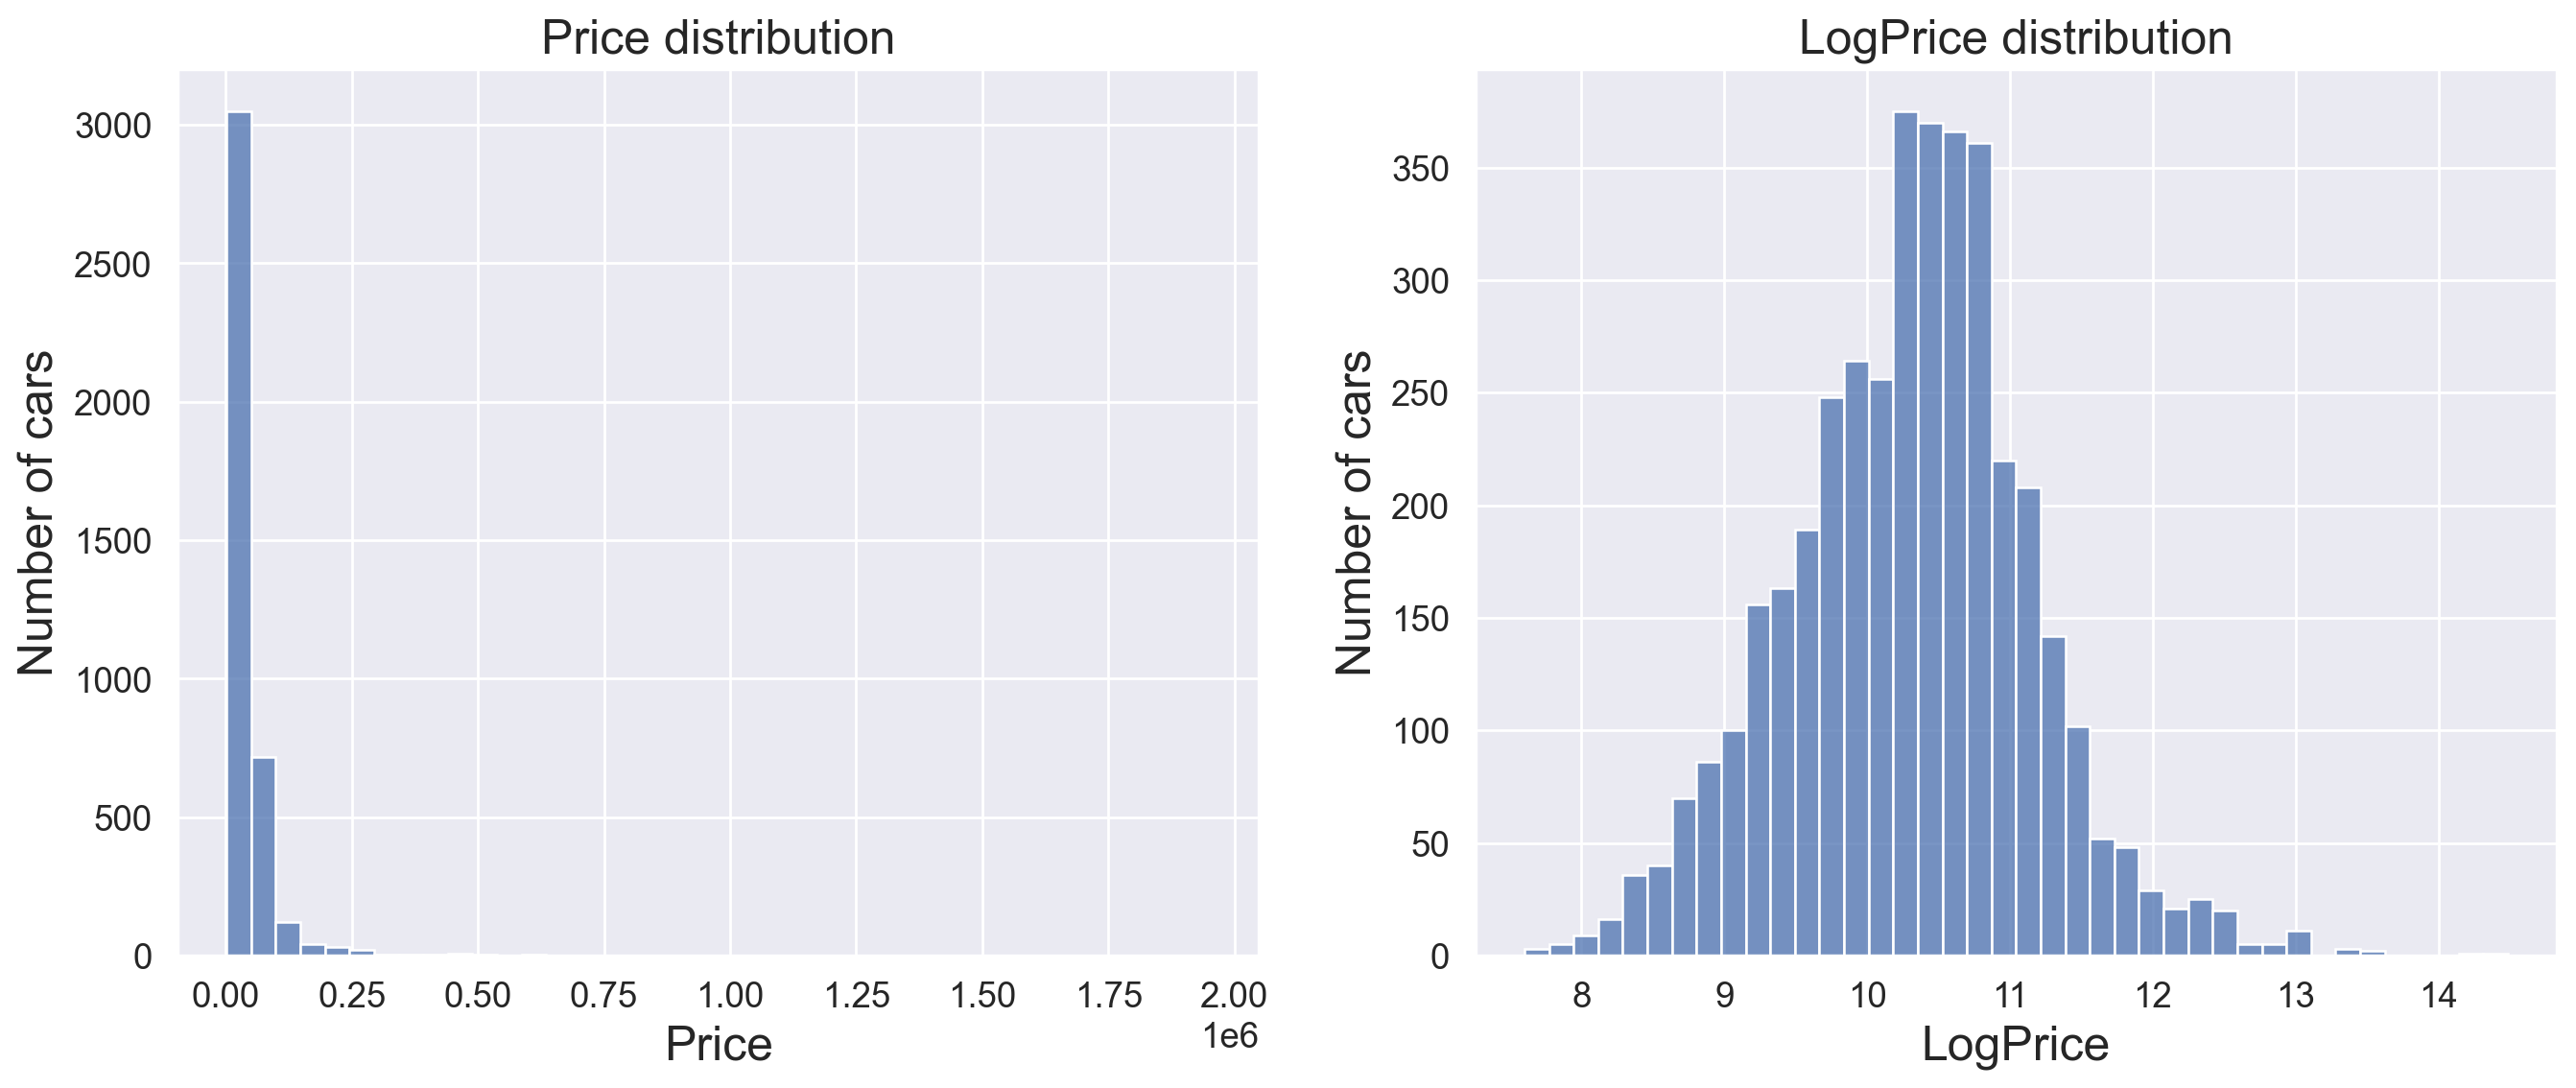

In [526]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(data.price, bins=40, ax=axs[0])
axs[0].set_xlabel('Price', fontsize=18)
axs[0].set_ylabel('Number of cars', fontsize=18)
axs[0].set_title('Price distribution', fontsize=18)

axs[1] = sns.histplot(np.log1p(data.price), bins=40, ax=axs[1])
axs[1].set_xlabel('LogPrice', fontsize=18)
axs[1].set_ylabel('Number of cars', fontsize=18)
axs[1].set_title('LogPrice distribution', fontsize=18);

In [527]:
data['log_price'] = np.log(data["price"])

**Мини-вывод:** исходное распределение стоимости автомобиля является логнормальным: существует нижняя грань цены авто, в то же время верхняя грань практически не ограничена из-за существования суперкаров/коллекционных авто. Логарифмирование таргета делает распределение близким к нормальному.

## 2.3 Data split

Анализ для решения заполнения пропусков проводим только на трейне, чтобы не допустить утечки

In [528]:
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, random_state=21)
print(f"Train size = {data_train.shape[0]/data.shape[0]:.2%}, Test size = {data_test.shape[0]/data.shape[0]:.2%}")

Train size = 79.99%, Test size = 20.01%


## 2.1 Columns with missing values

In [529]:
cols_with_missings = data.isna().sum()[data.isna().sum() > 0].index
data[cols_with_missings].dtypes

fuel_type                 str
engine                    str
transmission              str
ext_col                   str
int_col                   str
accident                  str
clean_title               str
engine_volume         float64
engine_power          float64
trans_speed_number    float64
dtype: object

### 2.1.1 Numeric columns

- `trans_speed_number`

Область значений признака дискретная - можно посмотреть boxplot'ы и по ним оценить стоит ли выделять отдельную колонку с пропущенными значениями:

In [530]:
data_train["trans_speed_number"].value_counts(dropna=False)

trans_speed_number
NaN     1467
6.0      556
8.0      482
7.0      207
10.0     146
5.0      128
9.0       97
1.0       66
4.0       51
2.0        6
Name: count, dtype: int64

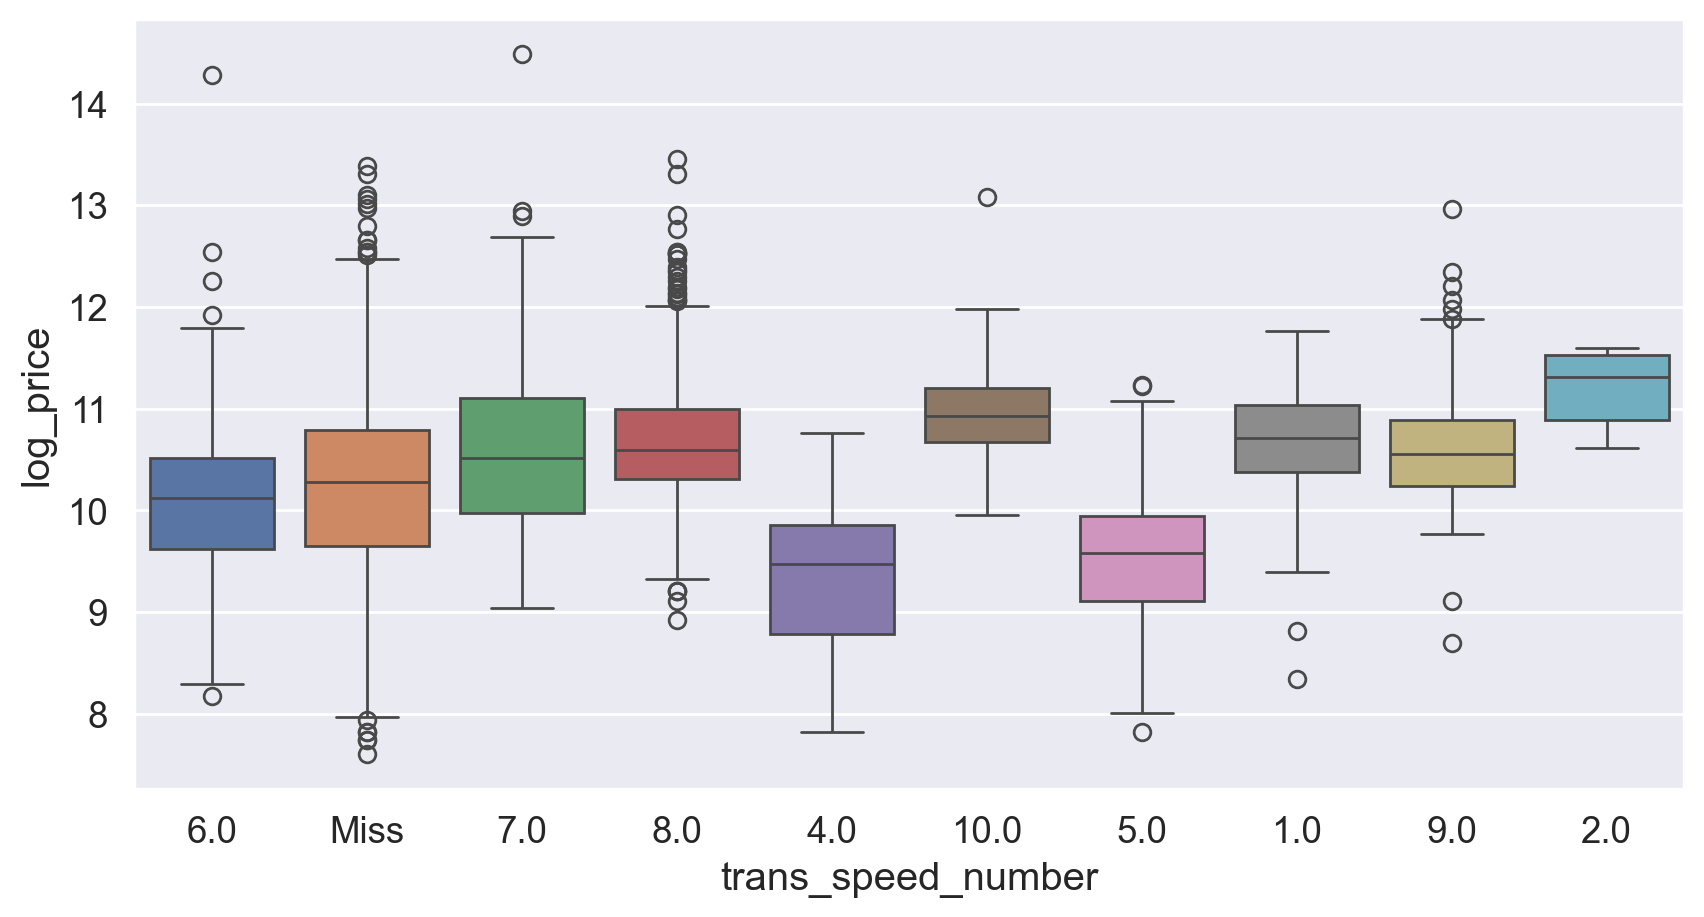

In [531]:
fig = plt.figure(figsize=(10, 5))
sns.boxplot(data=data_train.fillna("Miss"), hue="trans_speed_number", y="log_price", x="trans_speed_number", legend=None);

In [532]:
print(f"Mean price in cars with missing `trans_speed_number` = {data_train.loc[data_train["trans_speed_number"].isna(), "price"].mean().round(2)}") 
print(f"Mean price in cars with filled `trans_speed_number` = {data_train.loc[~data_train["trans_speed_number"].isna(), "price"].mean().round(2)}") 

Mean price in cars with missing `trans_speed_number` = 40979.81
Mean price in cars with filled `trans_speed_number` = 46938.77


- `engine_power`

In [533]:
print(f"Mean price in cars with missing `engine_power` = {data_train.loc[data_train["engine_power"].isna(), "price"].mean().round(2)}") 
print(f"Mean price in cars with filled `engine_power` = {data_train.loc[~data_train["engine_power"].isna(), "price"].mean().round(2)}") 

Mean price in cars with missing `engine_power` = 67026.63
Mean price in cars with filled `engine_power` = 38387.84


Видим сильное отличие средних мощностей для пропущенных и заполненных значений мощности двигателя, однако это может быть связано с типом машины (электрическая или нет) и дублировать информацию:

In [534]:
print("Machine engine type distribution with missing `engine_power` values")
data_train.loc[data_train["engine_power"].isna(), "is_electric"].value_counts()

Machine engine type distribution with missing `engine_power` values


is_electric
0    625
1     27
Name: count, dtype: int64

In [535]:
print("Machine engine type distribution with filled `engine_power` values")
data_train.loc[~data_train["engine_power"].isna(), "is_electric"].value_counts()

Machine engine type distribution with filled `engine_power` values


is_electric
0    2294
1     260
Name: count, dtype: int64

Предположение оказалось неверным: доля электрических машин с пропущенной мощностью даже меньше, чем обычных. Сам пропуск в значении `engine_power` должен быть мощым сигналом.

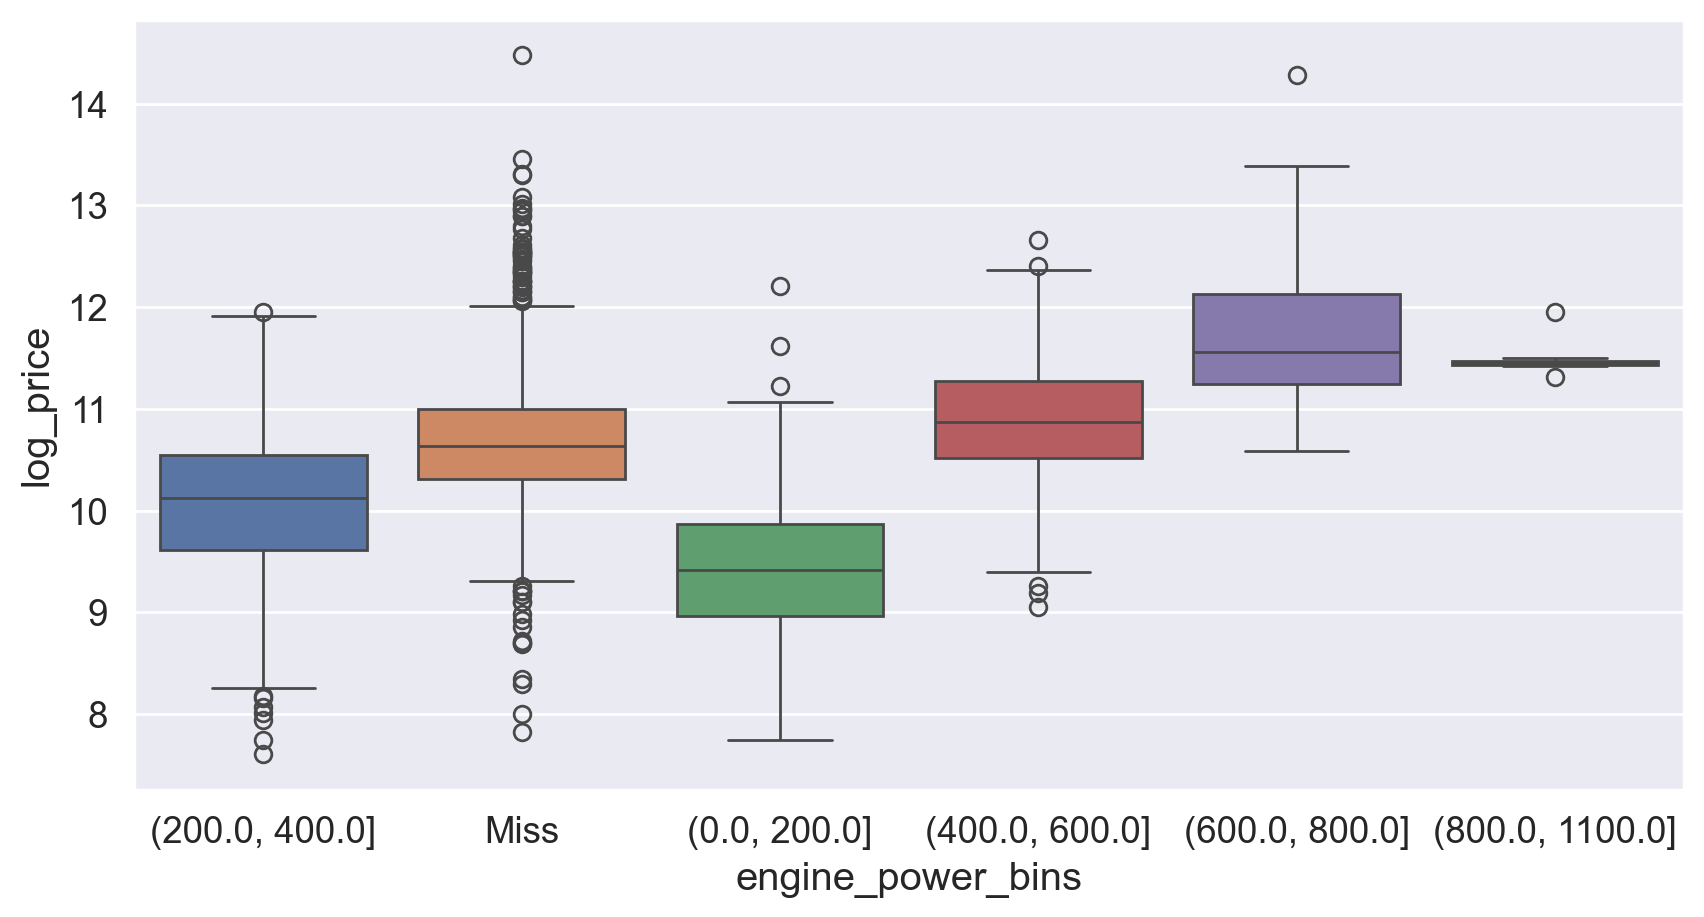

In [536]:
data_train["engine_power_bins"] = pd.cut(data_train["engine_power"], [0, 200, 400, 600, 800, 1100], right=True).astype(str)
fig = plt.figure(figsize=(10, 5))
sns.boxplot(data=data_train.fillna("Miss"), hue="engine_power_bins", y="log_price", x="engine_power_bins", legend=None);
data_train = data_train.drop(columns=["engine_power_bins"])

- `engine_volume`

In [537]:
print(f"Mean price in cars with missing `engine_volume` = {data_train.loc[data_train["engine_volume"].isna(), "price"].mean().round(2)}") 
print(f"Mean price in cars with filled `engine_volume` = {data_train.loc[~data_train["engine_volume"].isna(), "price"].mean().round(2)}") 

Mean price in cars with missing `engine_volume` = 45598.66
Mean price in cars with filled `engine_volume` = 44194.11


Значения таргета для заполненных и пропущенных значений слабо отличаются, вряд ли доп. признак флага будет полезен.

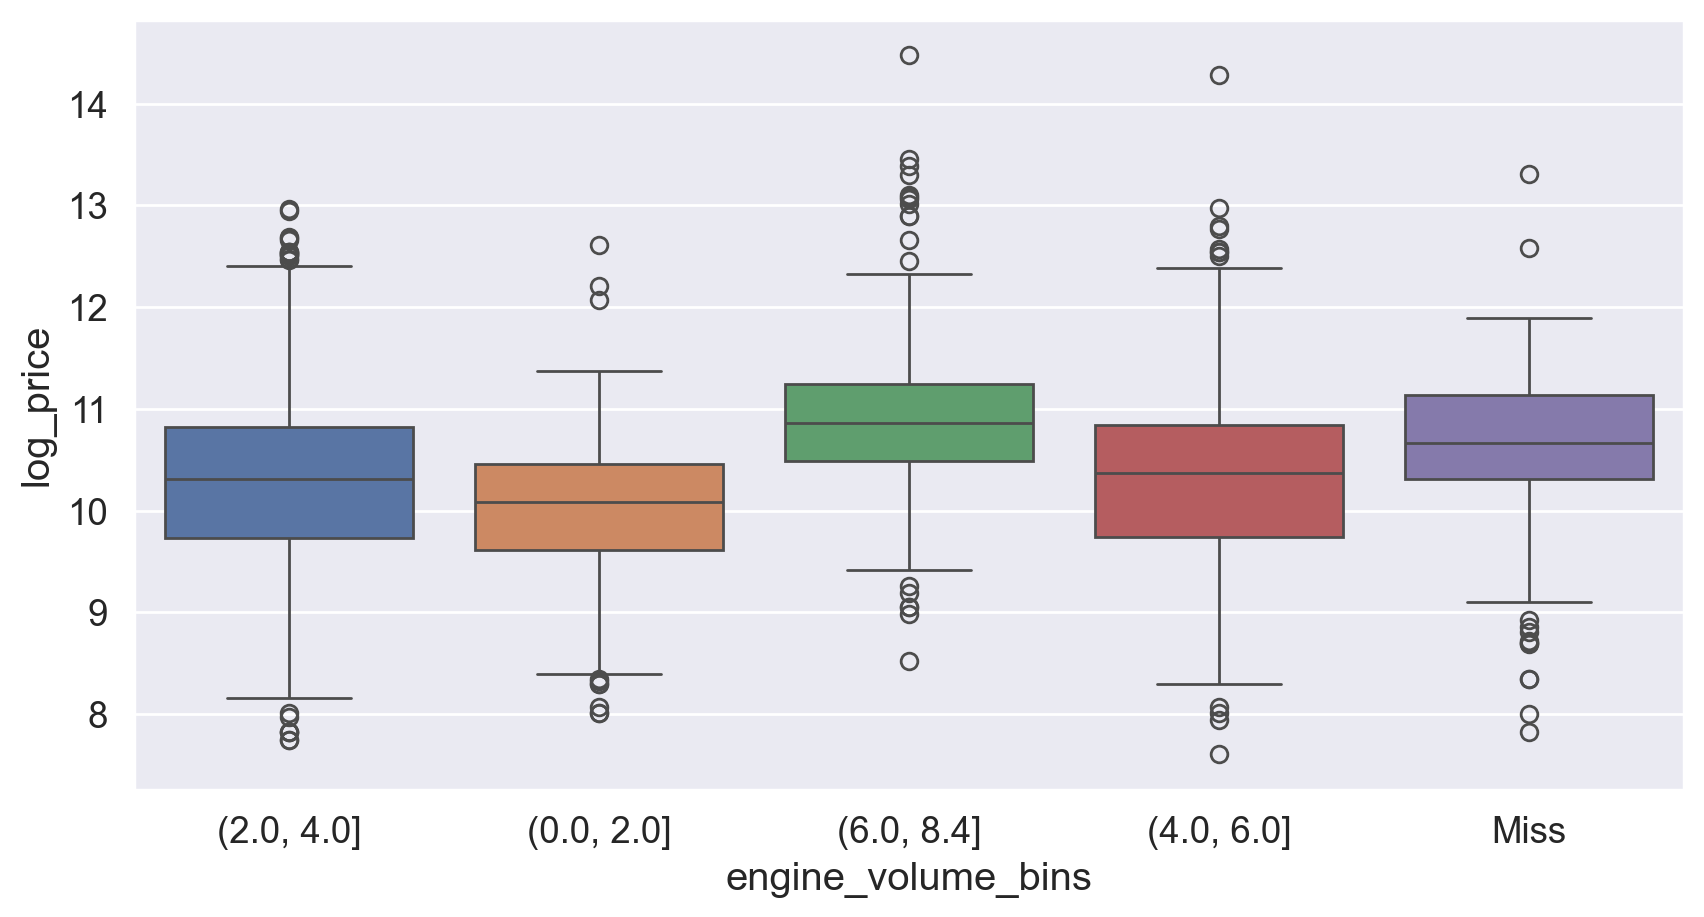

In [538]:
data_train["engine_volume_bins"] = pd.cut(data_train["engine_volume"], [0, 2, 4, 6, 8.4], right=True).astype(str)
fig = plt.figure(figsize=(10, 5))
sns.boxplot(data=data_train.fillna("Miss"), hue="engine_volume_bins", y="log_price", x="engine_volume_bins", legend=None);
data_train = data_train.drop(columns=["engine_volume_bins"])

Перед выводом раз посмотрим на доли пропусков доли пропусков в признаках:

In [539]:
data_train[["trans_speed_number", "engine_power", "engine_volume"]].isna().sum()/data_train.shape[0]

trans_speed_number    0.457580
engine_power          0.203369
engine_volume         0.012789
dtype: float64

**Вывод:**

- `trans_speed_number`: доля пропусков = 45.6%, среднее значение цены для заполненных машин = 46940, для машин с пропуском = 40980, распределения для цен в зависимости от значений признака существенно отличаются (включая пропущенной). ->

    **Гипотеза 2:** добавление бинарного признака пропуска `trans_speed_number_miss` может улучшить качество линейной регрессии.

    Ввиду того, что пропусков много будем использовать заполнение медианой с использованием группировки по `model` и `brand`
- `engine_power`: доля пропусков = 20.3%, среднее значение цены для заполненных машин = 38390, для машин с пропуском = 67030, распределения для цен в зависимости от значений признака очень сильно отличаются. ->

    **Гипотеза 3:** добавление бинарного признака пропуска `engine_power_miss` может улучшить сильно улучшить качество линейной      
    регрессии и стать одним из самых важных признаков.

    По аналогичной причине будем использовать заполнение медианой с использованием группировки по `model` и `brand`

- `engine_volume`: доля пропусков всего 0.01%, среднее значение цены для заполненных машин и для машин с пропуском практически не отличатся -> просто заполним пропуски глобальной медианой.

In [540]:
data_train["trans_speed_number_miss"] = data_train["trans_speed_number"].isna().astype(int)
data_train["engine_power_miss"] = data_train["engine_power"].isna().astype(int)

data_test["trans_speed_number_miss"] = data_test["trans_speed_number"].isna().astype(int)
data_test["engine_power_miss"] = data_test["engine_power"].isna().astype(int)

In [541]:
data_test.loc[data_test["engine_volume"].isna(), "engine_volume"] = data_train["engine_volume"].median()

Заполнение по медианам по группам заполняем в соответствии с [статьей](https://medium.com/@hasancem.demetci/enhancing-data-imputation-with-hierarchicalgroupimputer-a-case-study-on-tanzania-water-point-data-118162aa11ed):

In [542]:
class HierarchicalGroupImputer(BaseEstimator, TransformerMixin):
    def __init__(self, impute_cols, group_cols):
        self.impute_cols = impute_cols
        self.group_cols = group_cols

    def fit(self, X, y=None):
        self.global_medians = X[self.impute_cols].median()
        self.medians = {}
        for i in range(len(self.group_cols), 0, -1):
            group_subset = self.group_cols[:i]
            self.medians[tuple(group_subset)] = X.groupby(group_subset)[self.impute_cols].median()
        return self

    def transform(self, X, y=None):
        X_copy = X.copy()
        for index, row in X_copy.iterrows():
            for col in self.impute_cols:
                if not pd.isna(row[col]):
                    continue
                imputed = False
                for group_level in sorted(self.medians.keys(), key=len, reverse=True):
                    group_values = tuple(row[group_col] for group_col in group_level if group_col in X.columns)
                    if group_values in self.medians[group_level].index:
                        median_val = self.medians[group_level].loc[group_values, col]
                        if pd.notna(median_val):
                            X_copy.at[index, col] = median_val
                            imputed = True
                            break
                if not imputed:
                    X_copy.at[index, col] = self.global_medians[col]
        return X_copy

In [543]:
group_median_imputer = HierarchicalGroupImputer(impute_cols=["trans_speed_number", "engine_power"], group_cols=["brand", "model"])
group_median_imputer.fit(data_train)
data_test = group_median_imputer.transform(data_test)

### 2.1.2 Categorical columns

- `engine` and `transmission`

`engine` и `transmission` использовать напрямую не будем, лишь для сравнения с добавлением новых распаршенных дли них. Поэтому просто заменим значение пропуска на строку "Miss"

In [544]:
print(f"Number of missing values in `engine` = {data_train["engine"].isna().sum()}")
print(f"Number of missing values in `transmission` = {data_train["transmission"].isna().sum()}")

Number of missing values in `engine` = 37
Number of missing values in `transmission` = 2


In [545]:
data_train["engine"] = data_train["engine"].fillna("Miss")
data_train["transmission"] = data_train["transmission"].fillna("Miss")

data_test["engine"] = data_test["engine"].fillna("Miss")
data_test["transmission"] = data_test["transmission"].fillna("Miss")

- `ext_col` и `int_col`

In [546]:
print(f"Number of missing values in `ext_col` = {data_train["ext_col"].isna().sum()}")
print(f"Mean price in cars with missing `ext_col` = {data_train.loc[data_train["ext_col"].isna(), "price"].mean().round(2)}") 
print(f"Mean price in cars with filled `ext_col` = {data_train.loc[~data_train["ext_col"].isna(), "price"].mean().round(2)}") 

Number of missing values in `ext_col` = 12
Mean price in cars with missing `ext_col` = 131293.25
Mean price in cars with filled `ext_col` = 43884.91


In [547]:
data_train.loc[data_train["ext_col"].isna(), "price"]

915     197750
1004    238900
1151    114998
422      58900
63       23998
2909     44775
608      55998
987      43900
506      87500
1286     40900
1508    599000
1306     68900
Name: price, dtype: int64

Видим, что средний ценник существенно выше при пропуске в `ext_col`, причем это вызвано не наличием пропусков у самых дорогих машин. Это мог бы быть сильный сигнал, но пропусков всего 12 -> будем заменять их глобальной модой.

In [548]:
data_test.loc[data_test["ext_col"].isna(), "ext_col"] = data_train["ext_col"].mode()[0]

In [549]:
print(f"Number of missing values in `int_col` = {data_train["int_col"].isna().sum()}")
print(f"Mean price in cars with missing `int_col` = {data_train.loc[data_train["int_col"].isna(), "price"].mean().round(2)}") 
print(f"Mean price in cars with filled `int_col` = {data_train.loc[~data_train["int_col"].isna(), "price"].mean().round(2)}") 

Number of missing values in `int_col` = 105
Mean price in cars with missing `int_col` = 50945.75
Mean price in cars with filled `int_col` = 43984.07


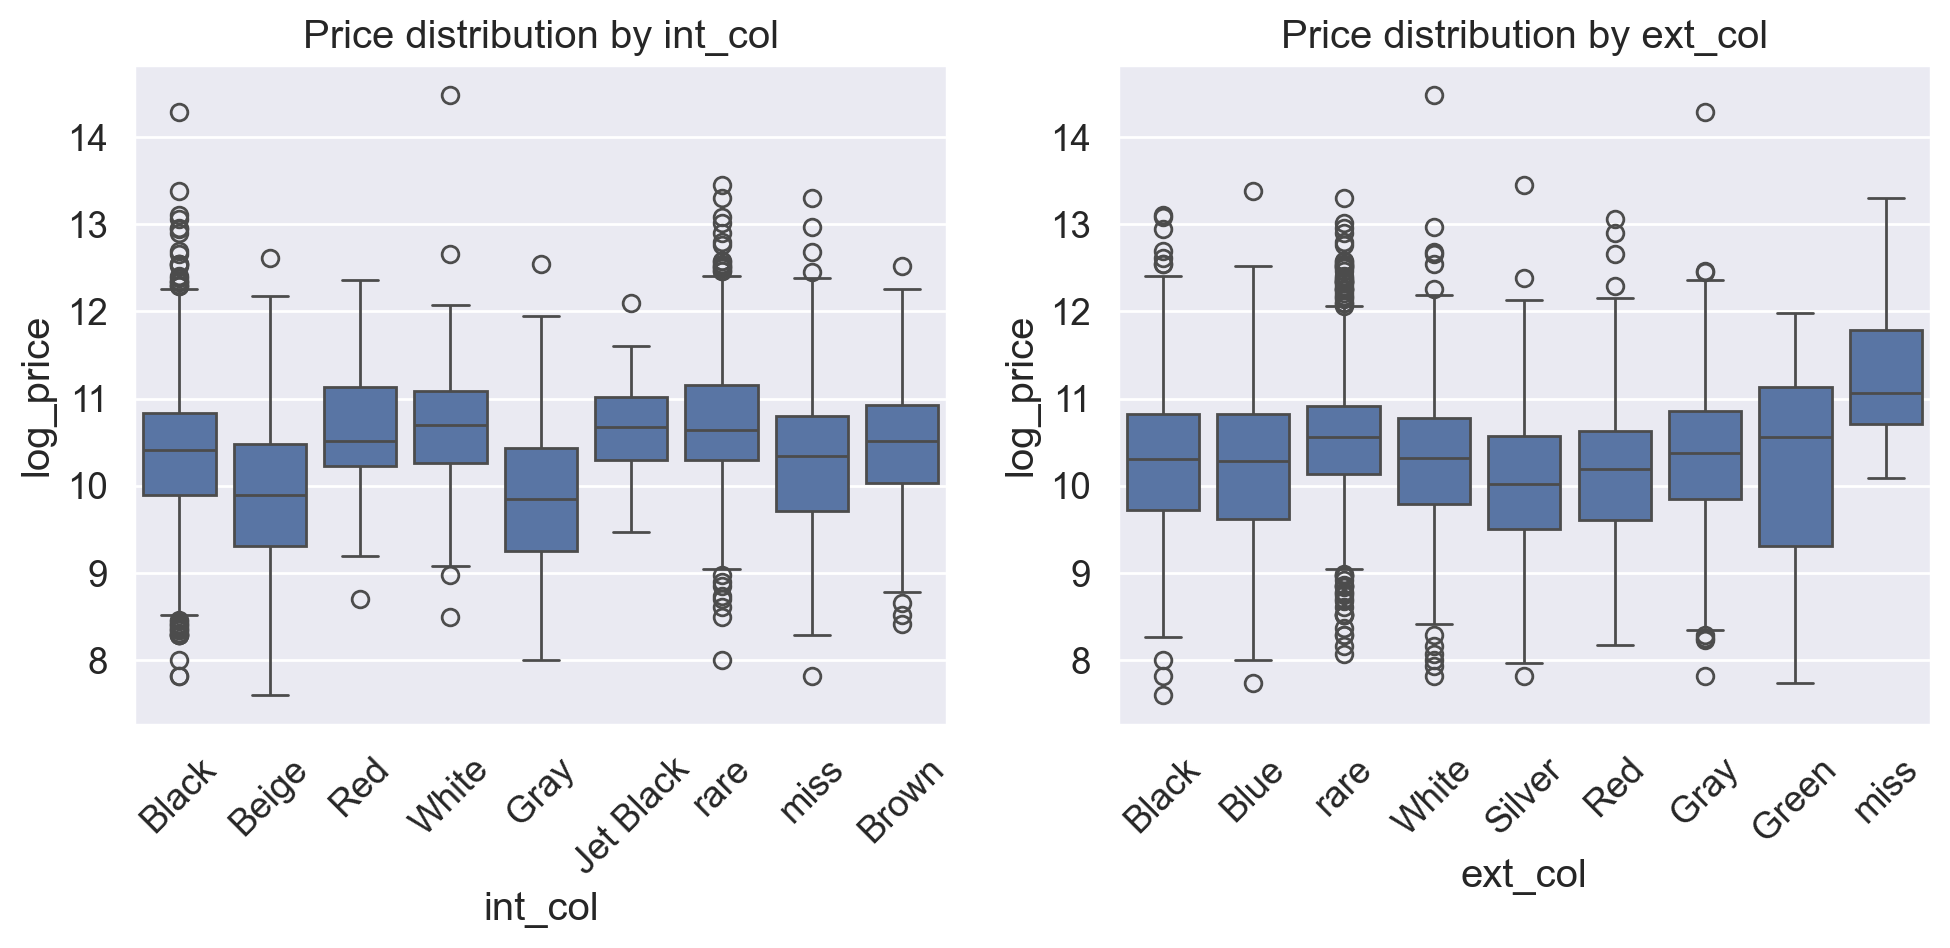

In [550]:
top_n = 7

features = ['int_col', 'ext_col']
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for i, feature in enumerate(features):
    col = data_train[feature].fillna("miss")
    top_cats = col[col != "miss"].value_counts().head(top_n).index.tolist()
    
    col_plot = col.where(col.isin(top_cats + ["miss"]), "rare")

    sns.boxplot(x=col_plot, y='log_price', data=data_train, ax=axs[i], legend=None)
    axs[i].set_title(f'Price distribution by {feature}')
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel('log_price')
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Есть разница средних цен для заполненых и пропущенных машин -> создадим отдельную категорию:

In [551]:
data_train["int_col"] = data_train["int_col"].fillna("Miss")
data_test["int_col"] = data_test["int_col"].fillna("Miss")

In [552]:
cols_with_missings

Index(['fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident',
       'clean_title', 'engine_volume', 'engine_power', 'trans_speed_number'],
      dtype='str')

- `fuel_type`, `accident` and `clean_title` 

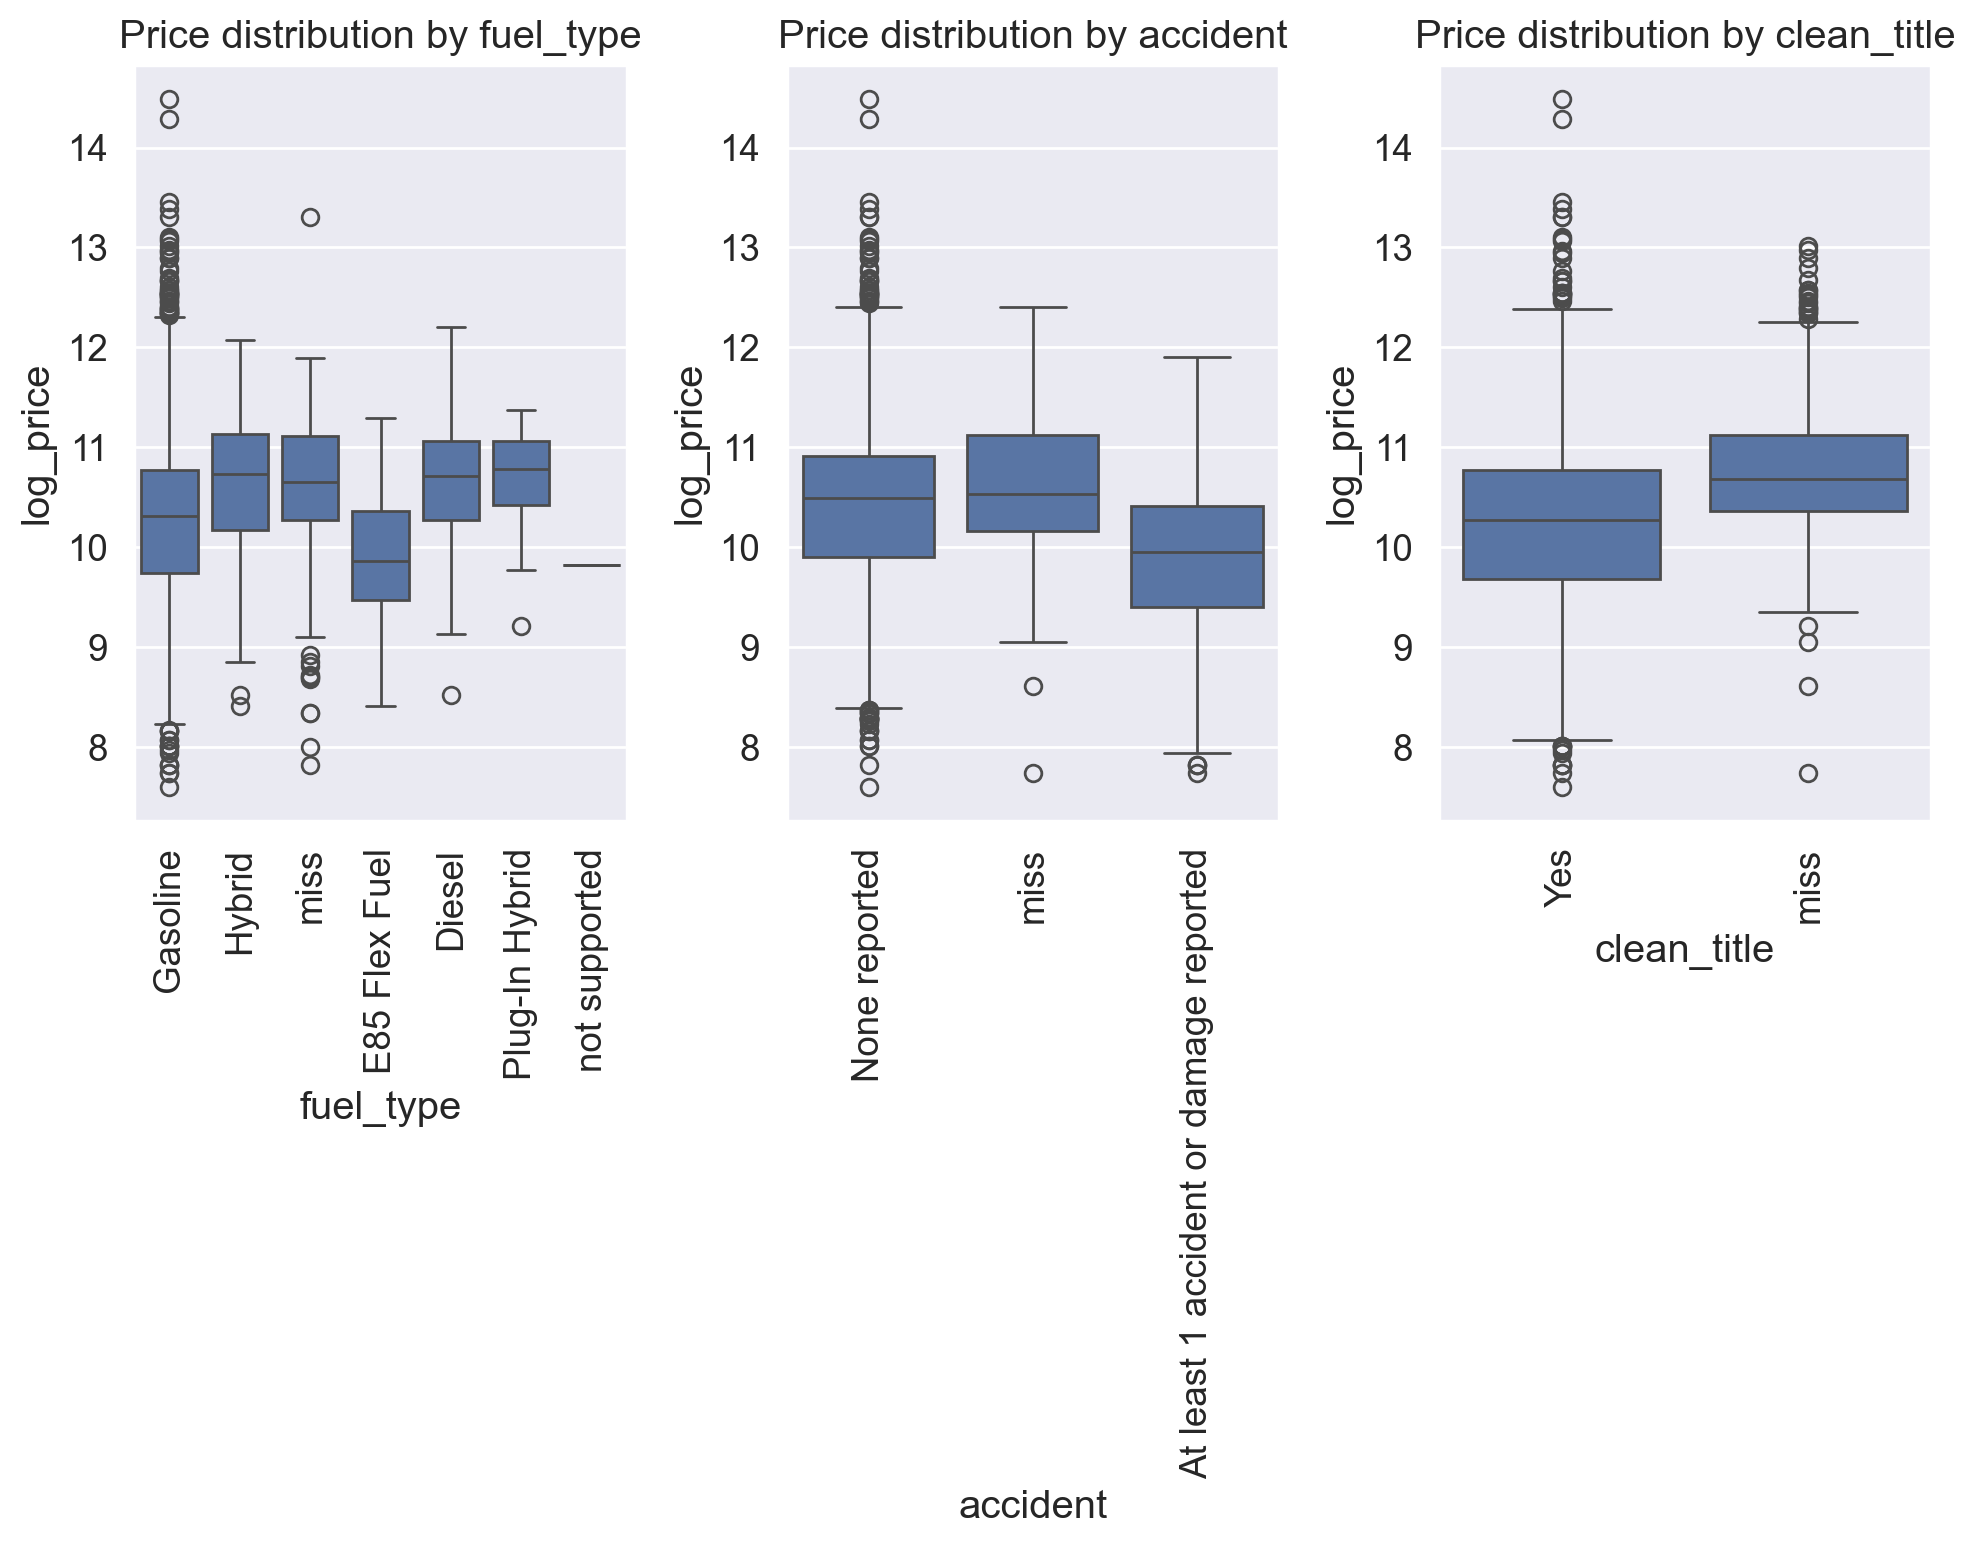

In [553]:
top_n = 7

features = ['fuel_type', 'accident', 'clean_title']
fig, axs = plt.subplots(1, 3, figsize=(10, 8))

for i, feature in enumerate(features):
    col = data_train[feature].fillna("miss")
    top_cats = col[col != "miss"].value_counts().head(top_n).index.tolist()
    
    col_plot = col.where(col.isin(top_cats + ["miss"]), "rare")

    sns.boxplot(x=col_plot, y='log_price', data=data_train, ax=axs[i])
    axs[i].set_title(f'Price distribution by {feature}')
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel('log_price')
    axs[i].tick_params(axis='x', rotation=90)

plt.tight_layout()

In [554]:
print(f"Number of missing values in `fuel_type` = {data_train["fuel_type"].isna().sum()}")
print(f"Mean price in cars with missing `fuel_type` = {data_train.loc[data_train["fuel_type"].isna(), "price"].mean().round(2)}") 
print(f"Mean price in cars with filled `fuel_type` = {data_train.loc[~data_train["fuel_type"].isna(), "price"].mean().round(2)}") 

Number of missing values in `fuel_type` = 179
Mean price in cars with missing `fuel_type` = 51347.88
Mean price in cars with filled `fuel_type` = 43790.1


In [555]:
print(f"Number of missing values in `accident` = {data_train["accident"].isna().sum()}")
print(f"Mean price in cars with missing `accident` = {data_train.loc[data_train["accident"].isna(), "price"].mean().round(2)}") 
print(f"Mean price in cars with filled `accident` = {data_train.loc[~data_train["accident"].isna(), "price"].mean().round(2)}") 

Number of missing values in `accident` = 85
Mean price in cars with missing `accident` = 51619.26
Mean price in cars with filled `accident` = 44010.34


In [556]:
print(f"Number of missing values in `clean_title` = {data_train["clean_title"].isna().sum()}")
print(f"Mean price in cars with missing `clean_title` = {data_train.loc[data_train["clean_title"].isna(), "price"].mean().round(2)}") 
print(f"Mean price in cars with filled `clean_title` = {data_train.loc[~data_train["clean_title"].isna(), "price"].mean().round(2)}") 

Number of missing values in `clean_title` = 476
Mean price in cars with missing `clean_title` = 62708.28
Mean price in cars with filled `clean_title` = 40987.09


Во всех 3-х признаках достаточно много пропусков, аналогично добавим категорию `Miss` - пропуск в данных. бинарны признак пропуска после `OHE` в `clean_title` может быть особенно полезным.


**Вывод:**

- `engine` и `transmission` будут использоваться только для проверки **Гипотезы 1**. Ввиду большого числа уникальных значений заполнение по моде некорректно, а прямое использования без выделения редких категорий может повлечь к переобучению моделей. Заполняем выделяя отдельную подкатегорию `Miss`
- `ext_col` содержит всего 12 пропусков, заполняем модой.
- `int_col` содержит 105 пропусков, существенное различие среднего таргета для пропусков и их отсутствия -> выделяем подкатегорию `Miss`
- `fuel_type` и `accident` содержат 179 и 85 пропусков соответственно, ситуация аналогичная `int_col` -> выделяем подкатегорию `Miss`
- `clean_title` содержит более 10% пропусков (476), константный -> признак нужно либо удалять, либо преобразовывать в бинарный с помощью выделения подкатегории `Miss`. Отличие среднего таргета для заполненных и пропущенных значений очень сильное -> добавляем значение пропуска и формулируем:

In [557]:
data_train["fuel_type"] = data_train["fuel_type"].fillna("Miss")
data_test["fuel_type"] = data_test["fuel_type"].fillna("Miss")

data_train["accident"] = data_train["accident"].fillna("Miss")
data_test["accident"] = data_test["accident"].fillna("Miss")

data_train["clean_title"] = data_train["clean_title"].fillna("Miss")
data_test["clean_title"] = data_test["clean_title"].fillna("Miss")

In [558]:
data_train.isna().sum()

brand                         0
model                         0
model_year                    0
milage                        0
fuel_type                     0
engine                        0
transmission                  0
ext_col                      12
int_col                       0
accident                      0
clean_title                   0
price                         0
engine_turbo                  0
engine_volume                41
is_electric                   0
engine_power                652
trans_speed_number         1467
transmission_type             0
log_price                     0
trans_speed_number_miss       0
engine_power_miss             0
dtype: int64

In [559]:
data_test.isna().sum()

brand                      0
model                      0
model_year                 0
milage                     0
fuel_type                  0
engine                     0
transmission               0
ext_col                    0
int_col                    0
accident                   0
clean_title                0
price                      0
engine_turbo               0
engine_volume              0
is_electric                0
engine_power               0
trans_speed_number         0
transmission_type          0
log_price                  0
trans_speed_number_miss    0
engine_power_miss          0
dtype: int64

## 2.2 Categorical features

### 2.2.1 Rare categories

Число уникальных значений в признаках:

In [560]:
data_train.select_dtypes(str).nunique()

brand                  56
model                1677
fuel_type               7
engine               1048
transmission           57
ext_col               287
int_col               140
accident                3
clean_title             2
transmission_type       6
dtype: int64

In [561]:
data_train.shape[0]

3206

**Мини-вывод:**

Уникальных значений во многих признаках слишком много - использование `OHE` неизбежно приведет к переобучению + тренировочная выборка состоит всего из 3206 машин - признаков станет больше машин -> можно использовать `TargetEncoding`, но значение признака будет оцениваться всего по нескольким объектам -> не выход. -> Будем выделять редкие категории 

In [562]:
#Сохраняем сырые, чтобы заполнять медиану для `engine_power` и `trans_speed_number` аналогично тесту
data_train["model_raw"] = data_train["model"] 
data_train["brand_raw"] = data_train["brand"]

In [563]:
def group_rare_categories(df, column_name, threshold, popular_category_values = None):
    data_inner = df.copy()
    if popular_category_values is None:
        popular_category_values = data_inner[column_name].value_counts()[(data_inner[column_name].value_counts() > threshold)].index.tolist()
    data_inner.loc[~data_inner[column_name].isin(popular_category_values), column_name] = "rare_or_new"
    return data_inner, popular_category_values

In [564]:
for col, threshold in zip(["model", "brand", "fuel_type", "engine", "transmission", "ext_col", "int_col"], [10, 40, 25, 15, 50, 20, 50]):
    data_train, popular_cats = group_rare_categories(data_train, col, threshold)
    data_test, popular_cats = group_rare_categories(data_test, col, threshold, popular_cats)

In [565]:
data_train.select_dtypes(str).nunique()

brand                  26
model                  21
fuel_type               6
engine                 25
transmission           14
ext_col                13
int_col                 8
accident                3
clean_title             2
transmission_type       6
model_raw            1677
brand_raw              56
dtype: int64

In [566]:
data_test.select_dtypes(str).nunique()

brand                26
model                17
fuel_type             6
engine               24
transmission         14
ext_col              13
int_col               8
accident              3
clean_title           2
transmission_type     6
dtype: int64

### 2.2.2 Categorical and binary features distribution

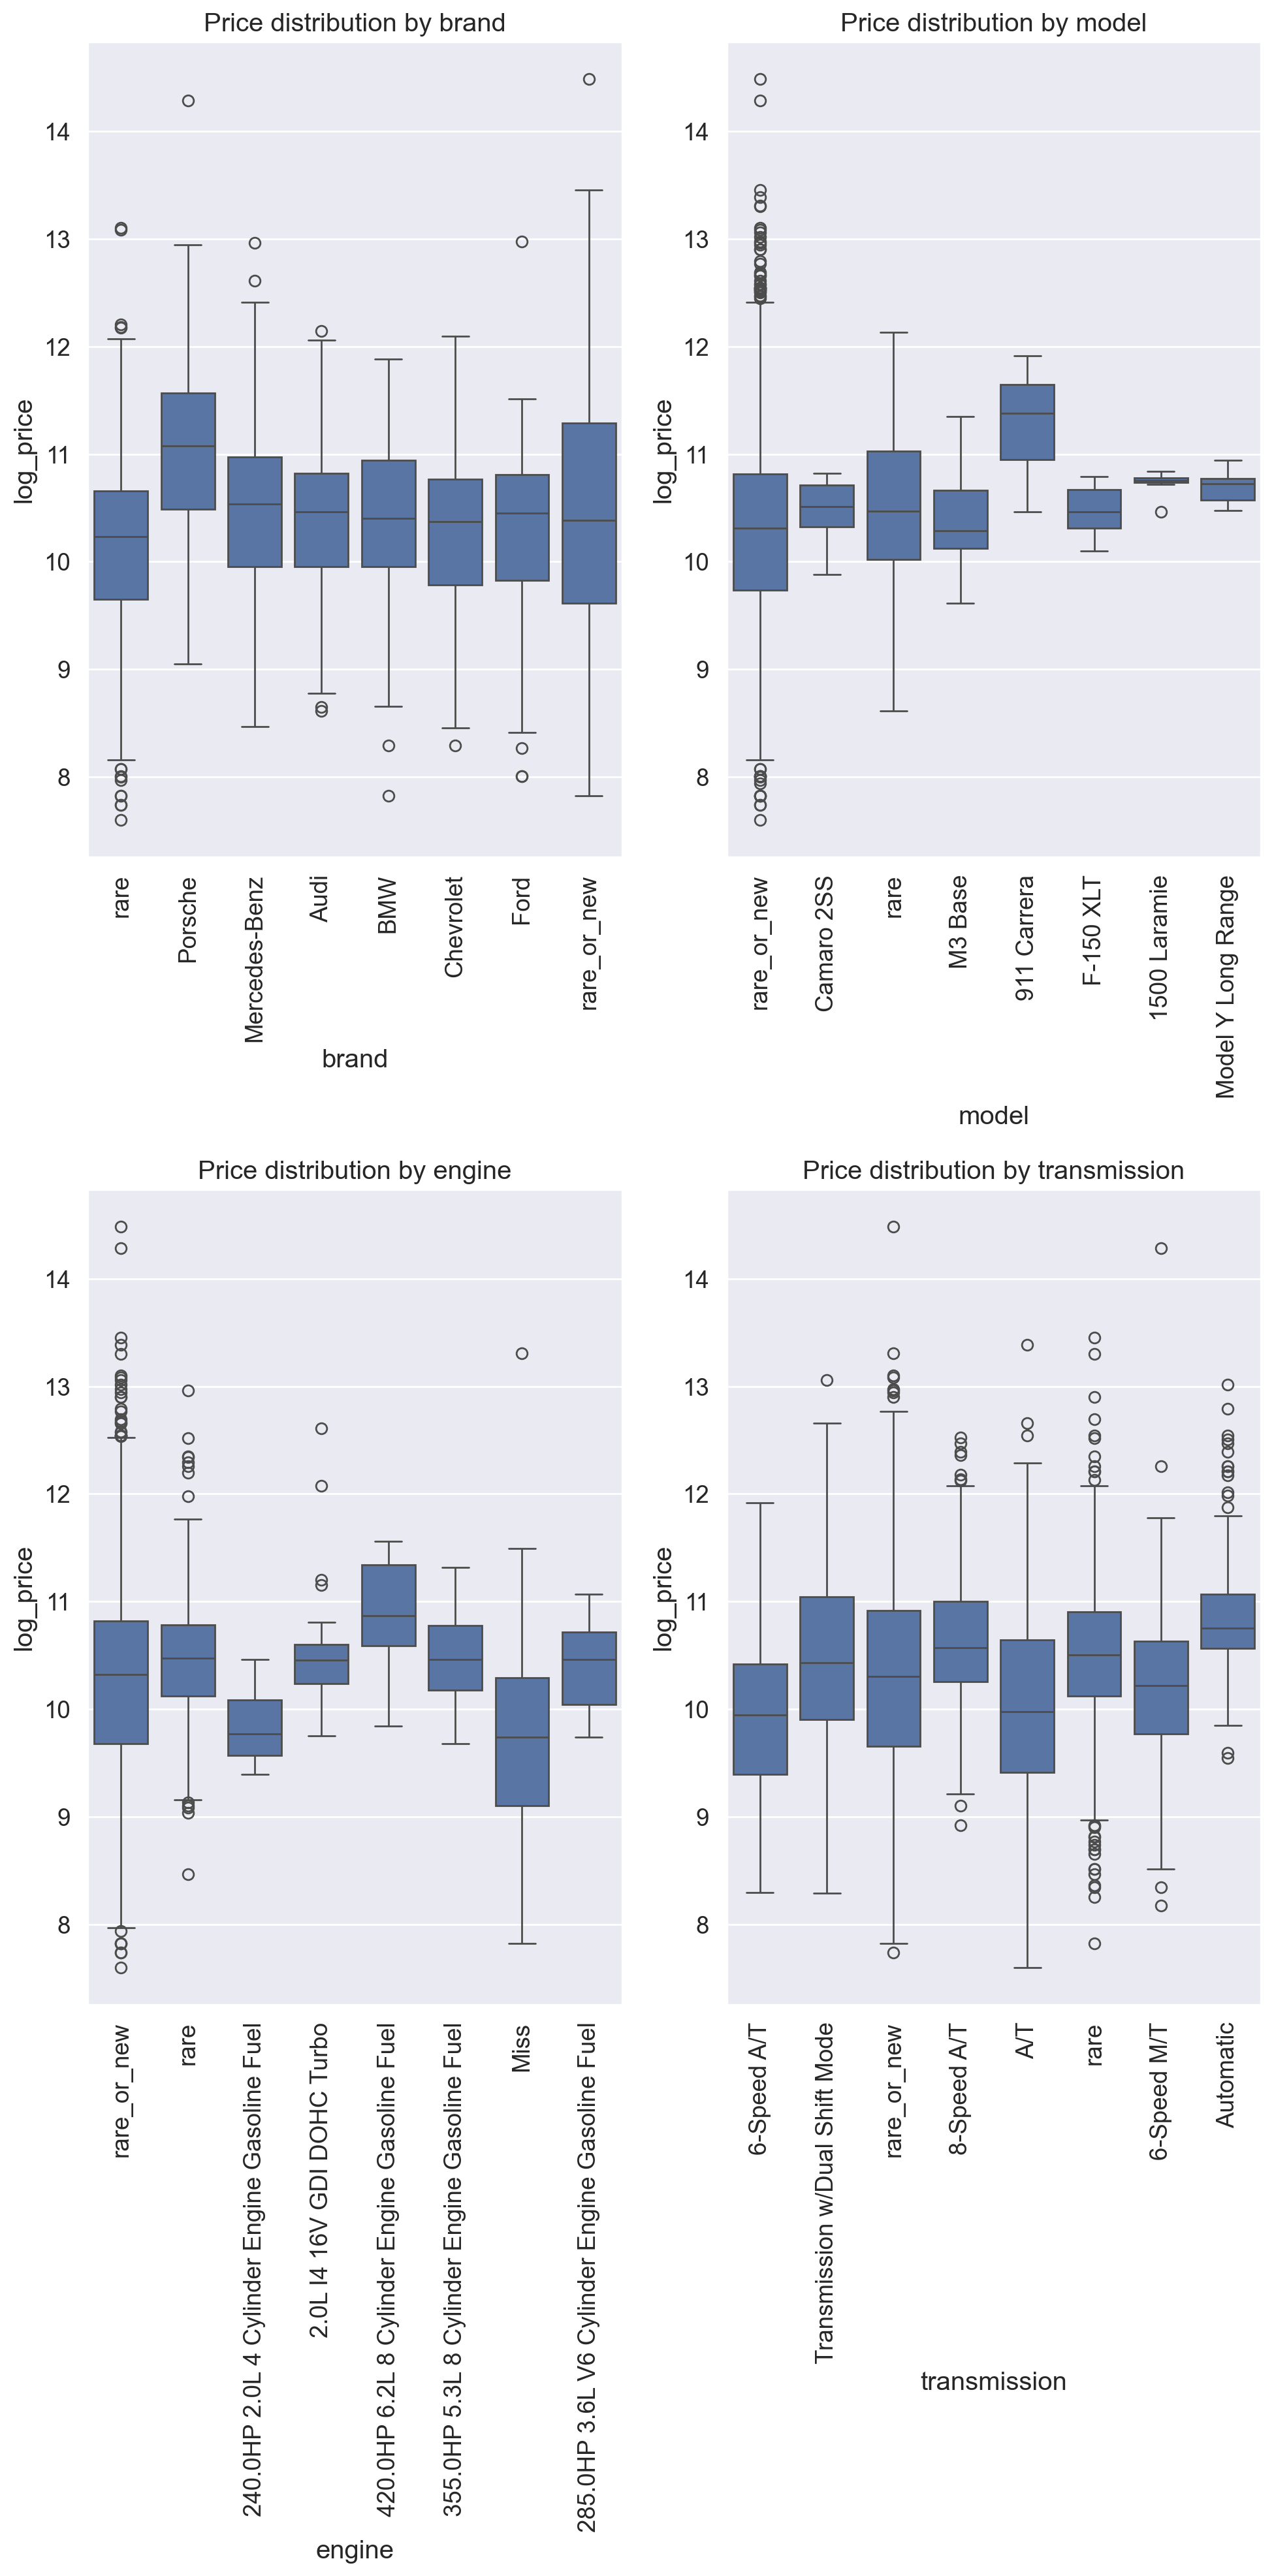

In [572]:
top_n = 7

features = ['brand', 'model', 'engine', 'transmission']
fig, axs = plt.subplots(2, 2, figsize=(10, 20))

axs = axs.reshape(-1)
for i, feature in enumerate(features):
    col = data_train[feature].fillna("miss")
    top_cats = col[col != "miss"].value_counts().head(top_n).index.tolist()
    
    col_plot = col.where(col.isin(top_cats + ["miss"]), "rare")

    sns.boxplot(x=col_plot, y='log_price', data=data_train, ax=axs[i])
    axs[i].set_title(f'Price distribution by {feature}')
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel('log_price')
    axs[i].tick_params(axis='x', rotation=90)

plt.tight_layout()

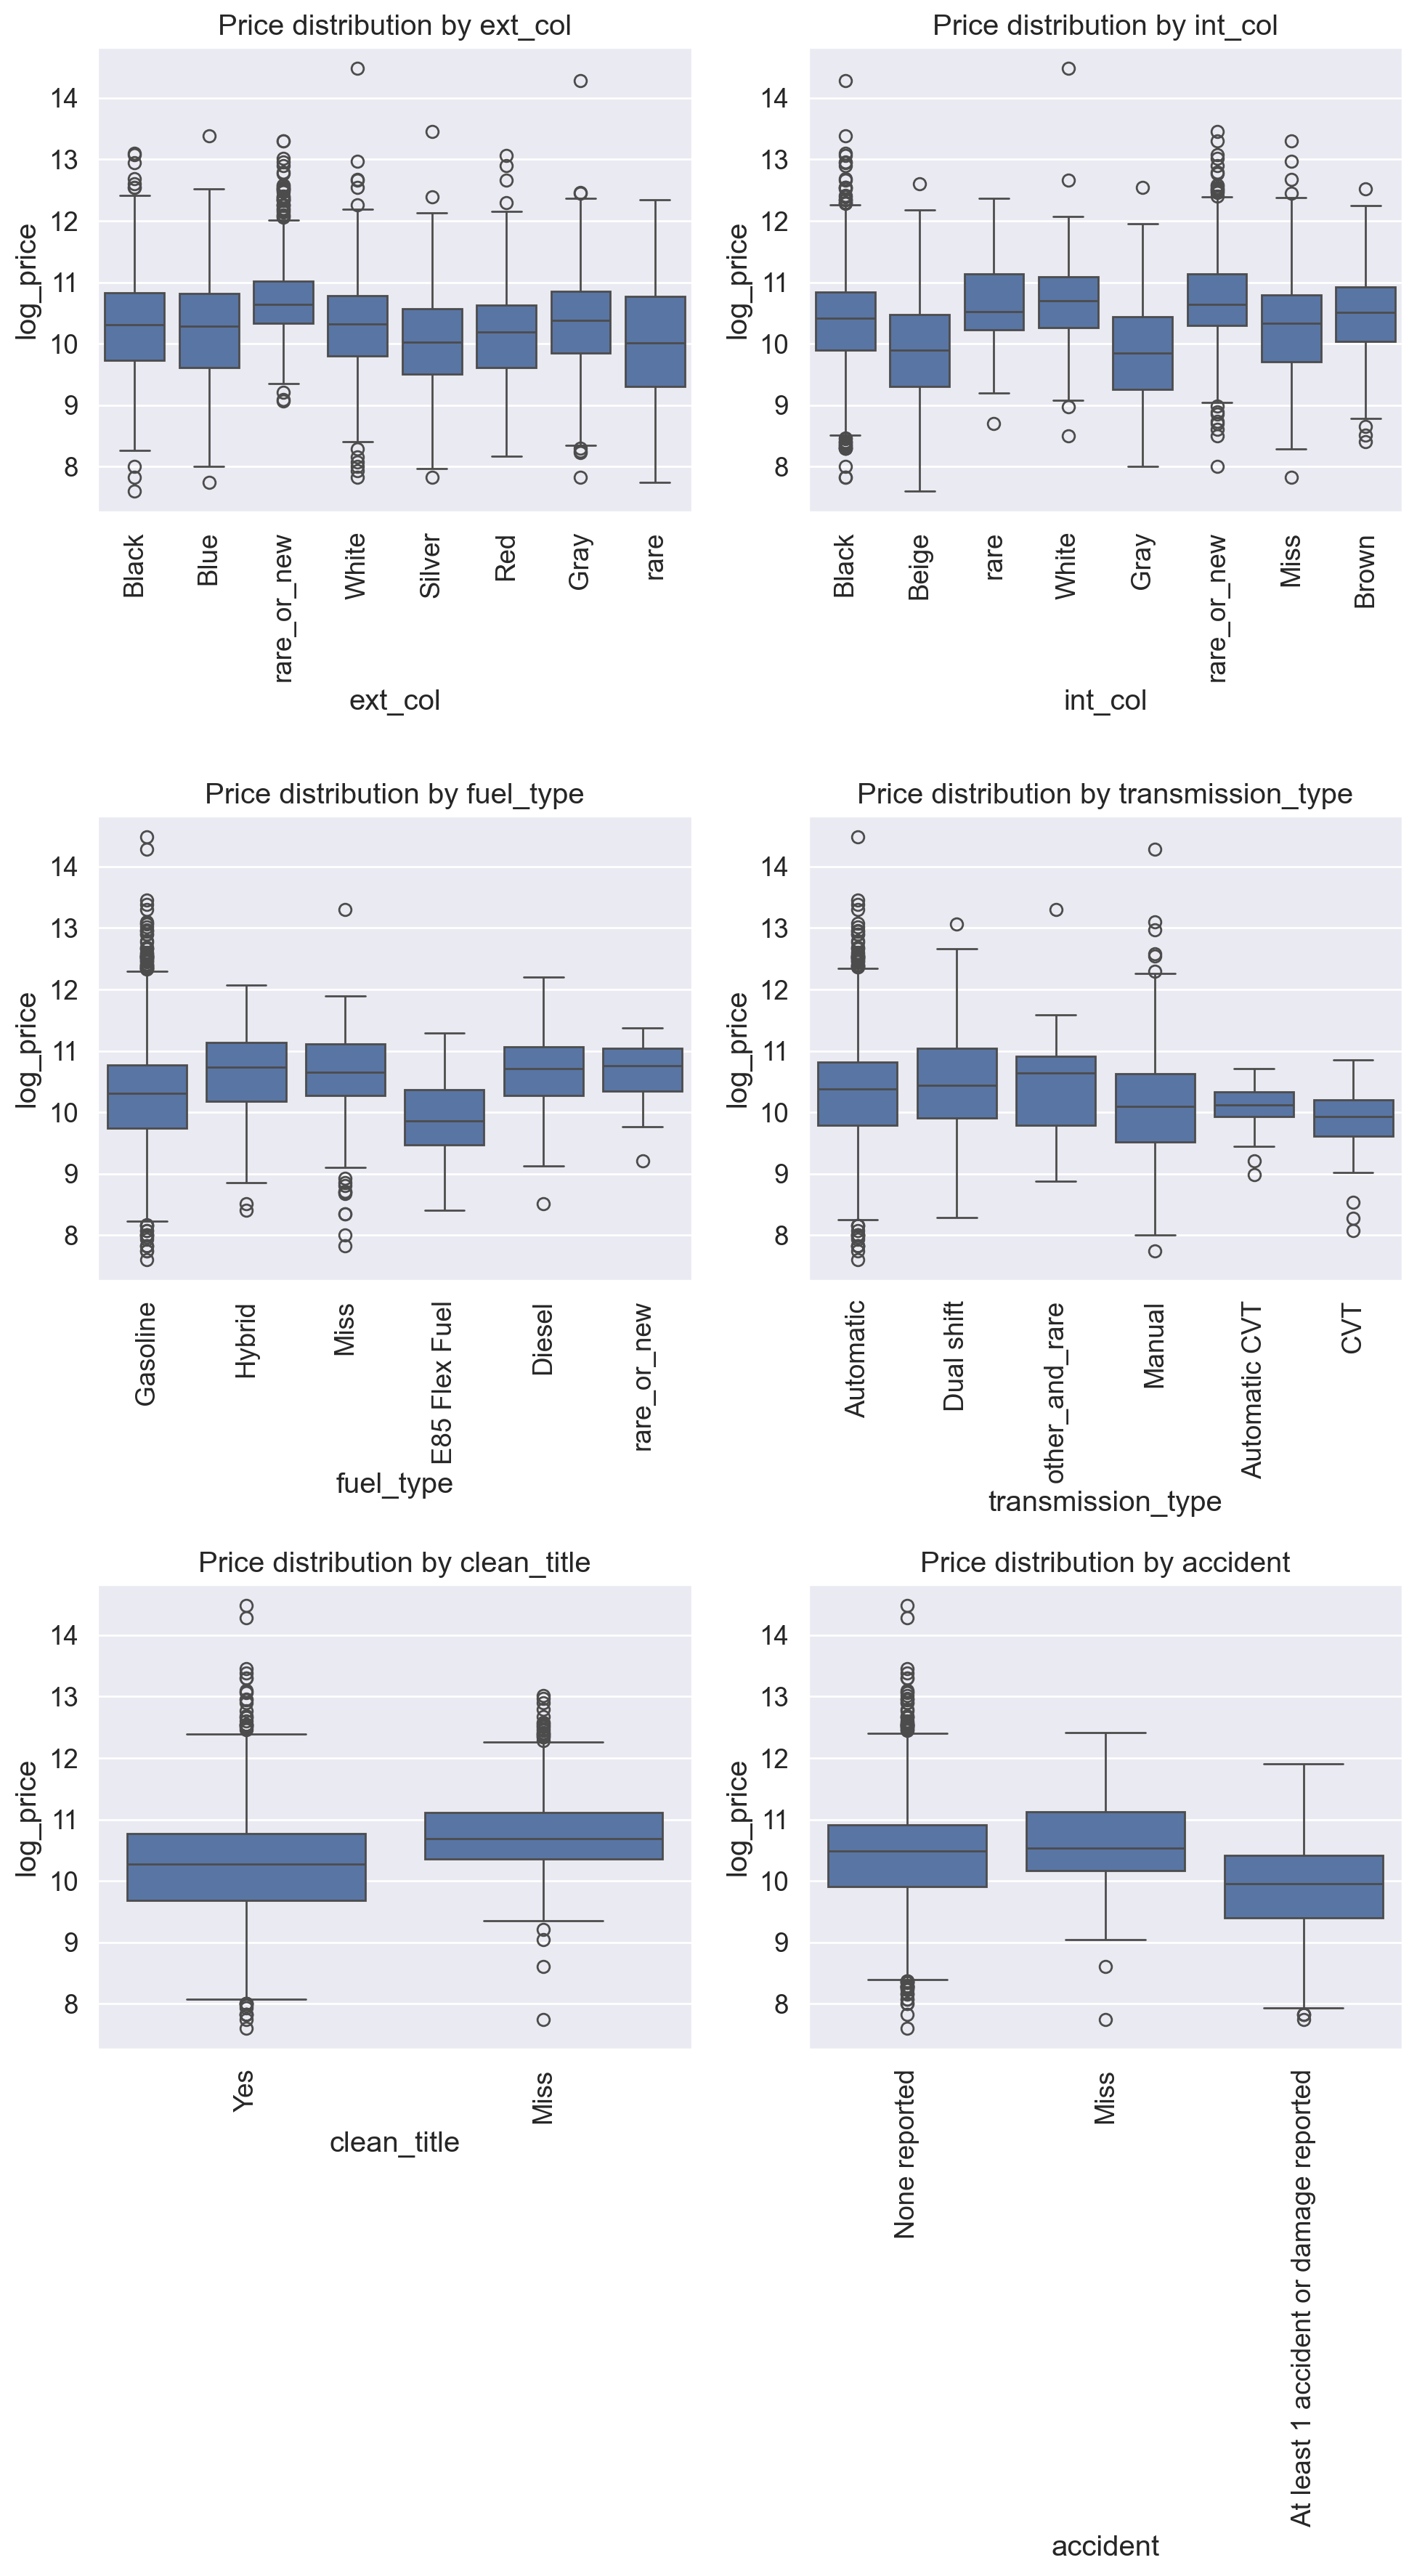

In [576]:
top_n = 7

features = ['ext_col', 'int_col', 'fuel_type', 'transmission_type', 'clean_title', 'accident']
fig, axs = plt.subplots(3, 2, figsize=(10, 18))

axs = axs.reshape(-1)
for i, feature in enumerate(features):
    col = data_train[feature].fillna("miss")
    top_cats = col[col != "miss"].value_counts().head(top_n).index.tolist()
    
    col_plot = col.where(col.isin(top_cats + ["miss"]), "rare")

    sns.boxplot(x=col_plot, y='log_price', data=data_train, ax=axs[i])
    axs[i].set_title(f'Price distribution by {feature}')
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel('log_price')
    axs[i].tick_params(axis='x', rotation=90)

plt.tight_layout()

In [ ]:
top_n = 7

features = ['ext_col', 'int_col', 'fuel_type', 'transmission_type', 'clean_title', 'accident']
fig, axs = plt.subplots(3, 2, figsize=(10, 18))

axs = axs.reshape(-1)
for i, feature in enumerate(features):
    col = data_train[feature].fillna("miss")
    top_cats = col[col != "miss"].value_counts().head(top_n).index.tolist()
    
    col_plot = col.where(col.isin(top_cats + ["miss"]), "rare")

    sns.boxplot(x=col_plot, y='log_price', data=data_train, ax=axs[i])
    axs[i].set_title(f'Price distribution by {feature}')
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel('log_price')
    axs[i].tick_params(axis='x', rotation=90)

plt.tight_layout()

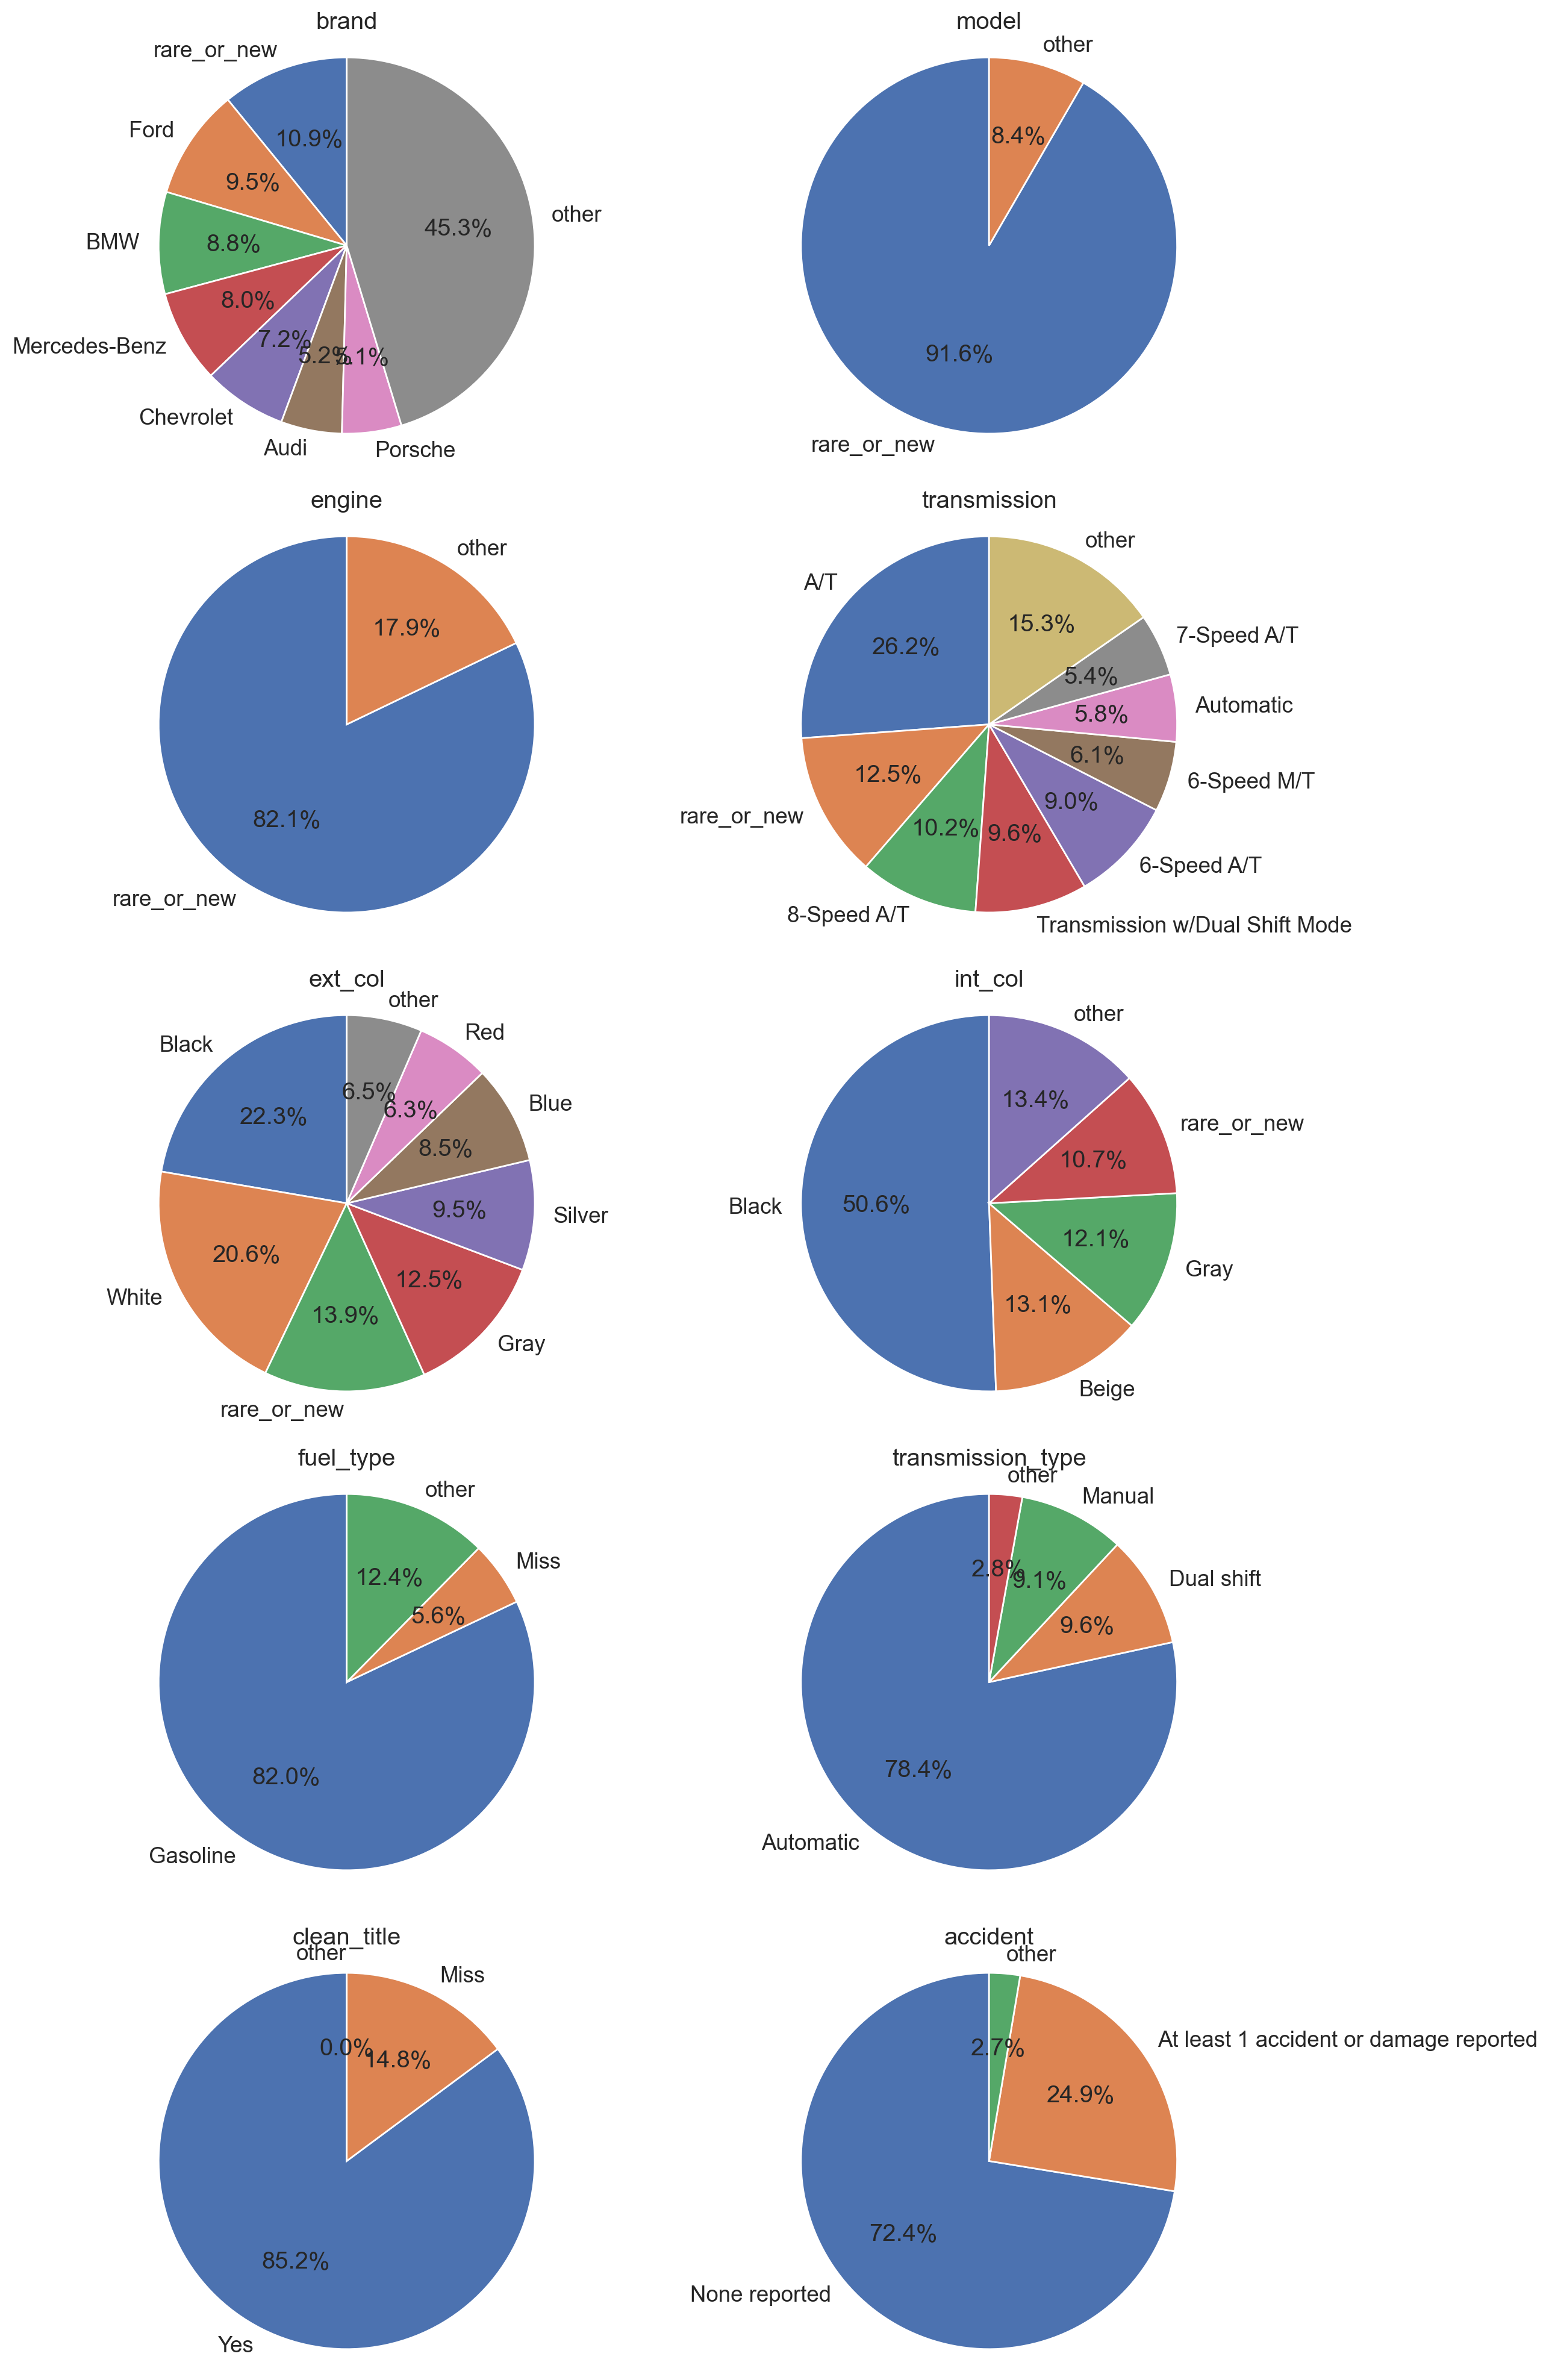

In [591]:
features_to_plot = ['brand', 'model', 'engine', 'transmission', 'ext_col', 'int_col', 'fuel_type', 'transmission_type', 'clean_title', 'accident']

fig, axs = plt.subplots(5, 2, figsize=(13, 20))
axs = axs.reshape(-1)

for i, feature in enumerate(features_to_plot):

    data_inner = data_train[feature].value_counts()

    rare_mask = data_inner / data_inner.sum() < 0.05
    rare_types = data_inner[rare_mask]
    
    data_inner = data_inner.drop(index=rare_types.index)
    data_inner = pd.concat([data_inner, pd.Series(rare_types.sum(), index=['other'])])
    
    axs[i].pie(data_inner, labels=data_inner.index, autopct='%1.1f%%', startangle=90)
    axs[i].set_title(f'{feature}')
    axs[i].axis('equal')

plt.tight_layout()

Бинарные за исключением `clean_title`:

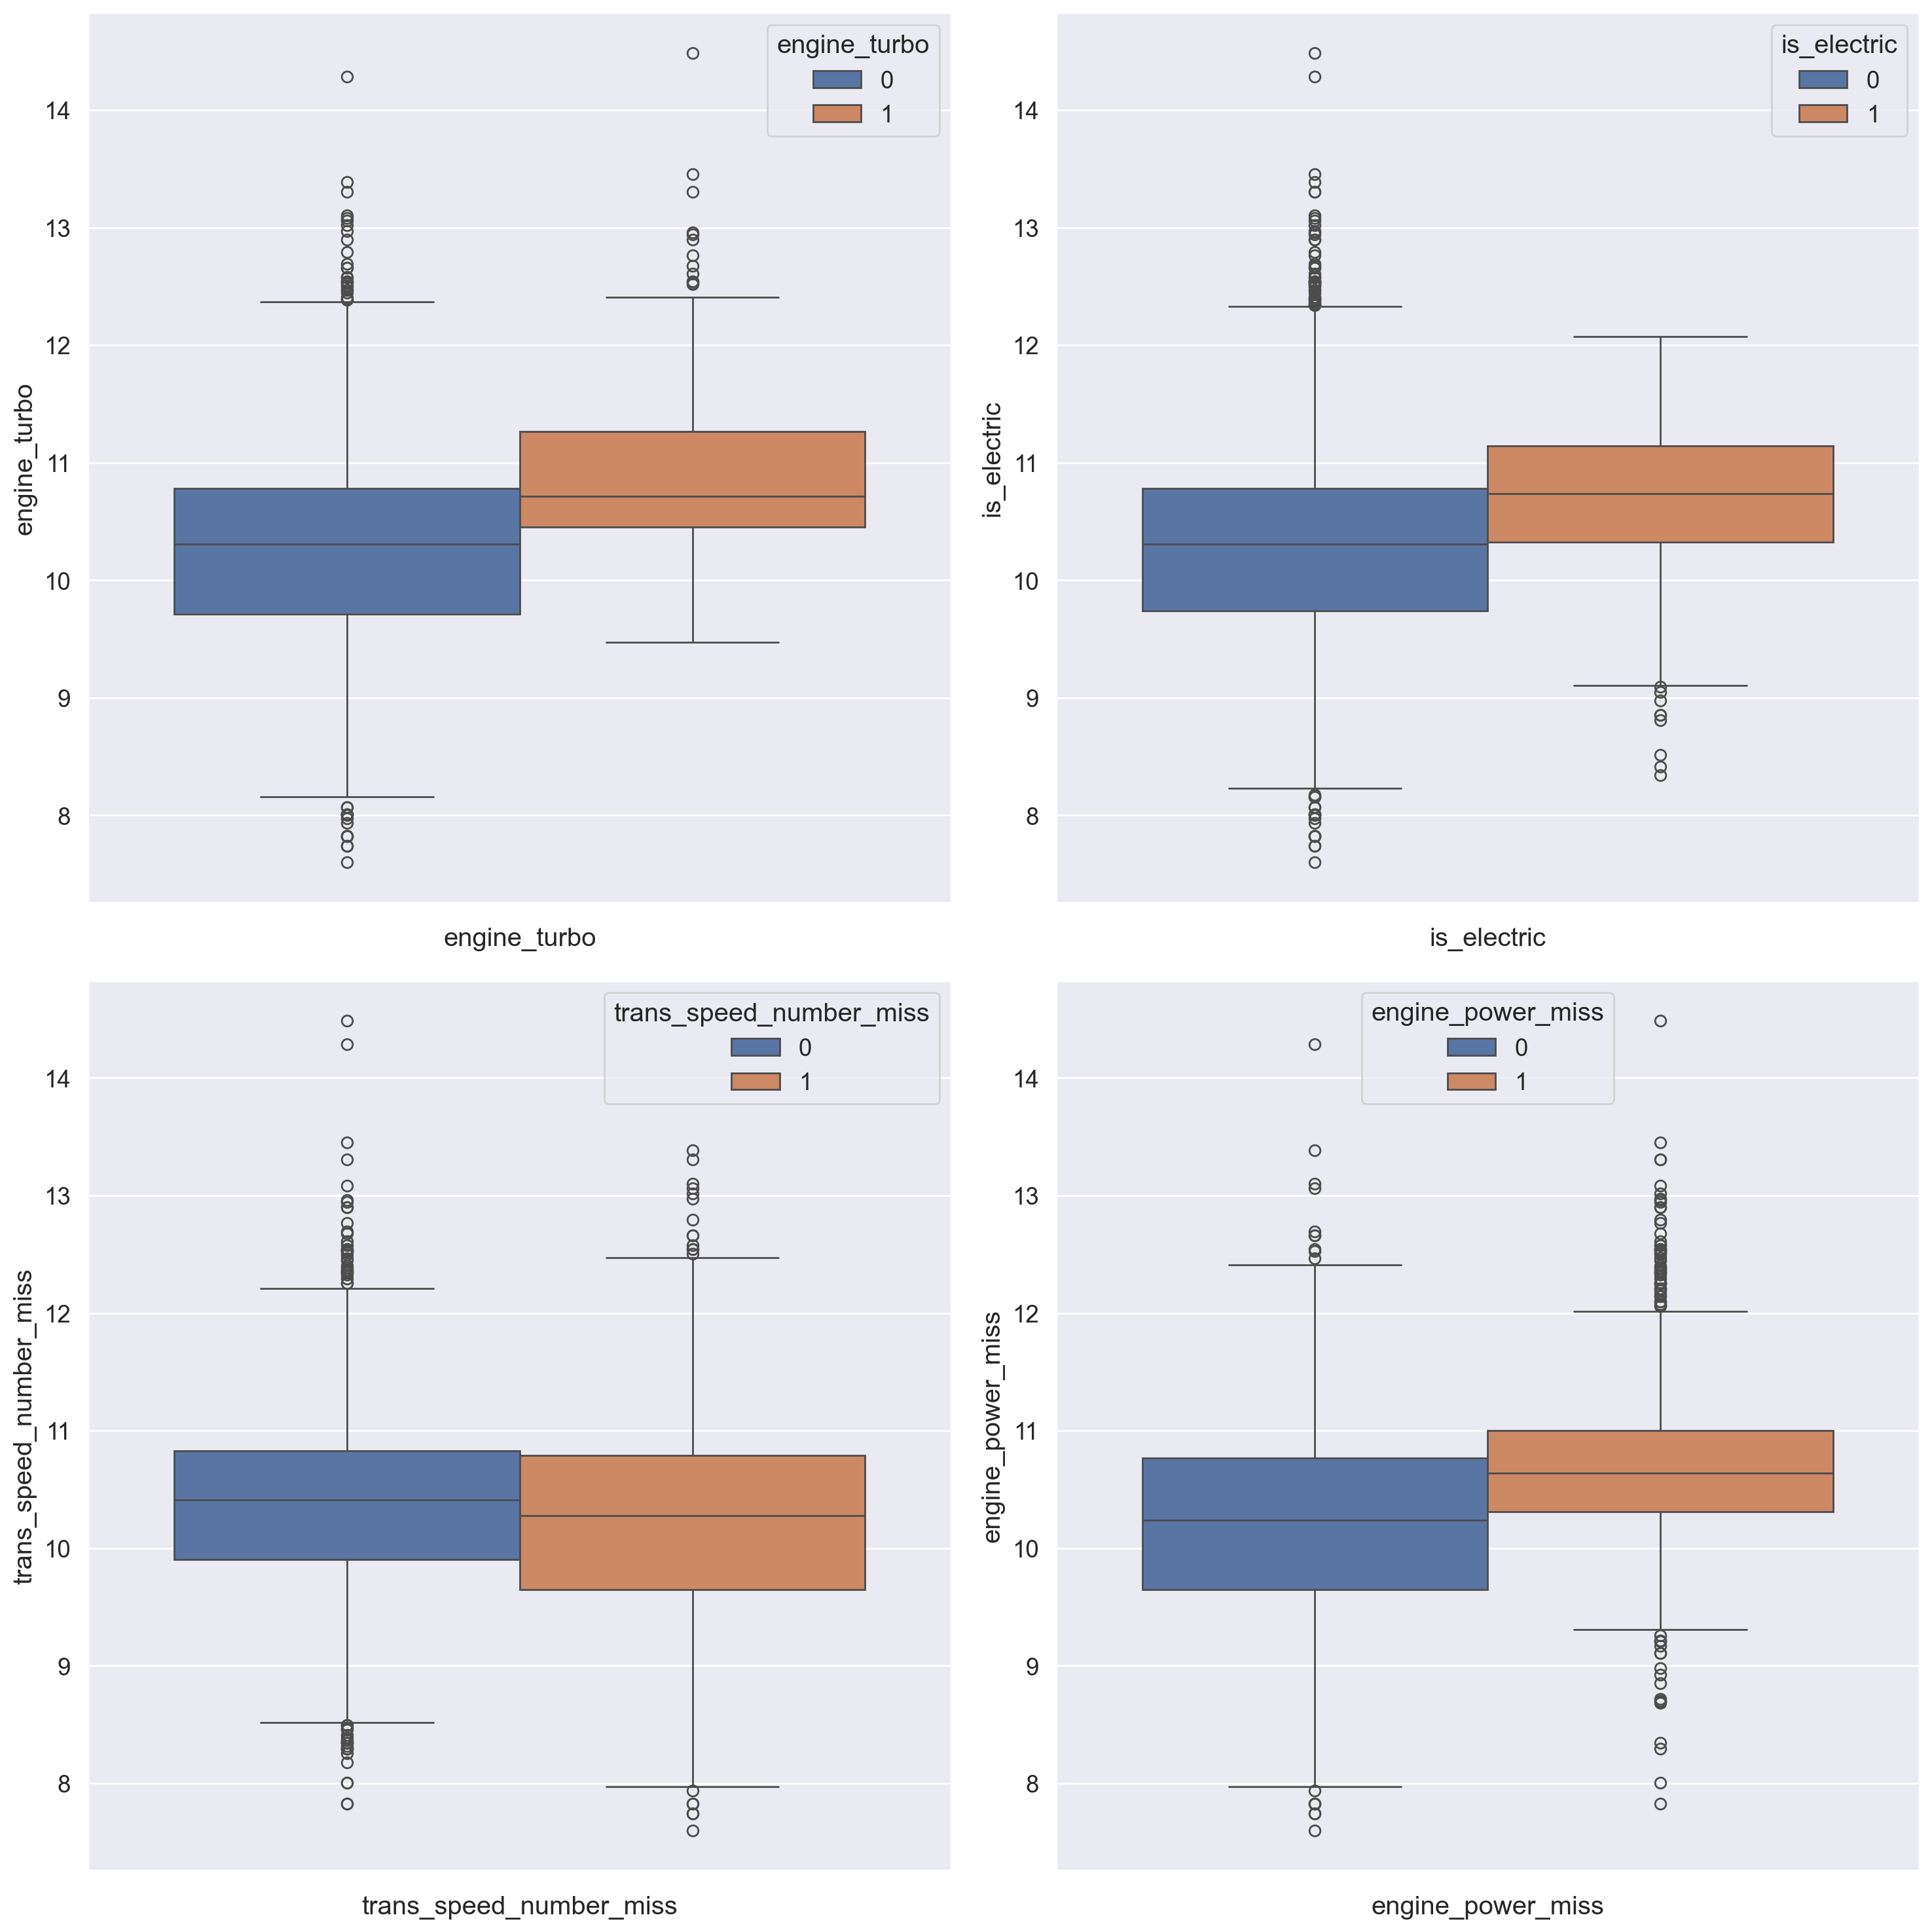

In [605]:
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
axs = axs.reshape(-1)

for i, feature in enumerate(["engine_turbo", "is_electric", "trans_speed_number_miss", "engine_power_miss"]):

    sns.boxplot(data=data_train, hue=feature, y="log_price", ax=axs[i])

    axs[i].set_ylabel(feature)
    axs[i].set_xlabel(feature)

plt.tight_layout()

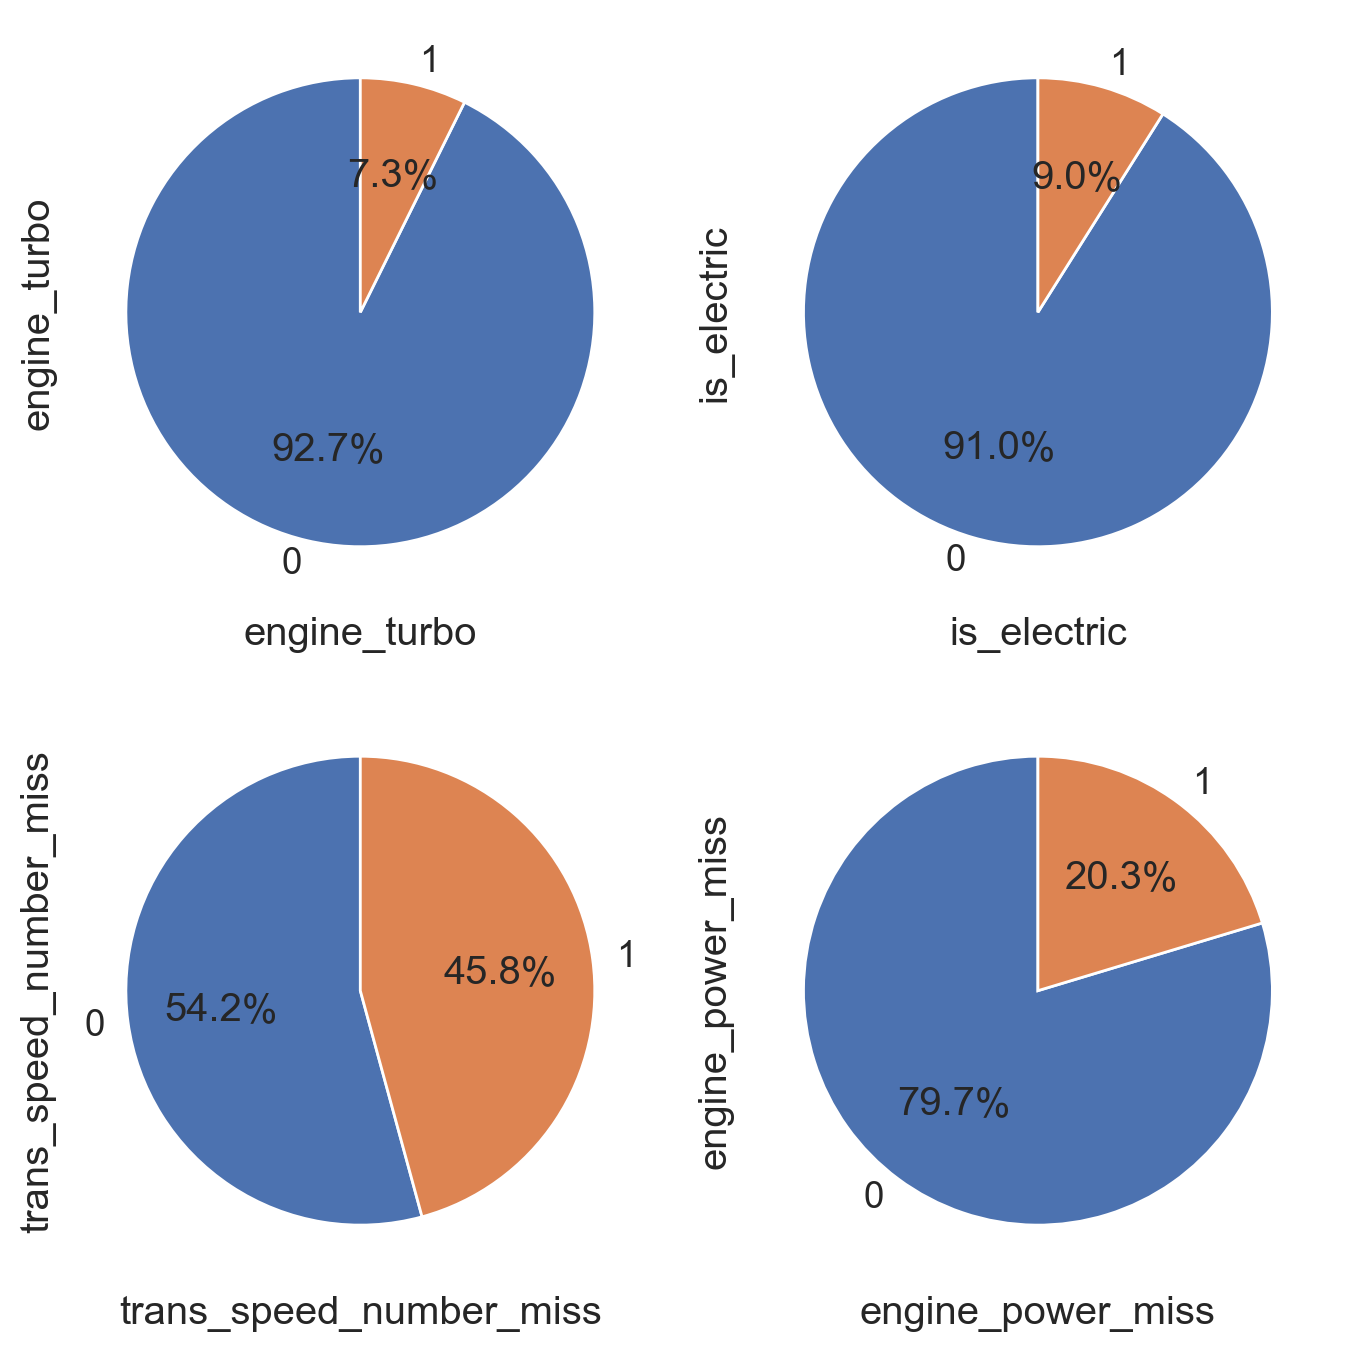

In [610]:
fig, axs = plt.subplots(2, 2, figsize=(7, 7))
axs = axs.reshape(-1)

for i, feature in enumerate(["engine_turbo", "is_electric", "trans_speed_number_miss", "engine_power_miss"]):

    # sns.boxplot(data=data_train, hue=feature, y="log_price", ax=axs[i])
    data_inner = data_train[feature].value_counts()
    axs[i].pie(data_inner, labels=data_inner.index, autopct='%1.1f%%', startangle=90)

    axs[i].set_ylabel(feature)
    axs[i].set_xlabel(feature)

plt.tight_layout()

**Вывод:**
- `brand` вряд ли будет сильным признаком - распределения логарифм цены на авто для разных брендов,за исключением *Porshe* (5.1%) и *rare* (10.9%), крайне похожи
- `ext_col` также вряд ли будут сильными - похожие распределения для разных значений, `int_col` должен иметь большее влияние, чем `ext_col` в итоговой модели
- Среди остальных признаков можно выделить `clean_title`, `accident`, `engine_turbo`, `is_electric` и `engine_power_miss` - сильно отличаются медианы и распределения для разных значений.


## 2.3 Numeric features

In [618]:
numeric_cols = data_train.select_dtypes("number").drop(columns=["price", "log_price", "engine_turbo", "is_electric", "engine_power_miss", "trans_speed_number_miss"]).columns

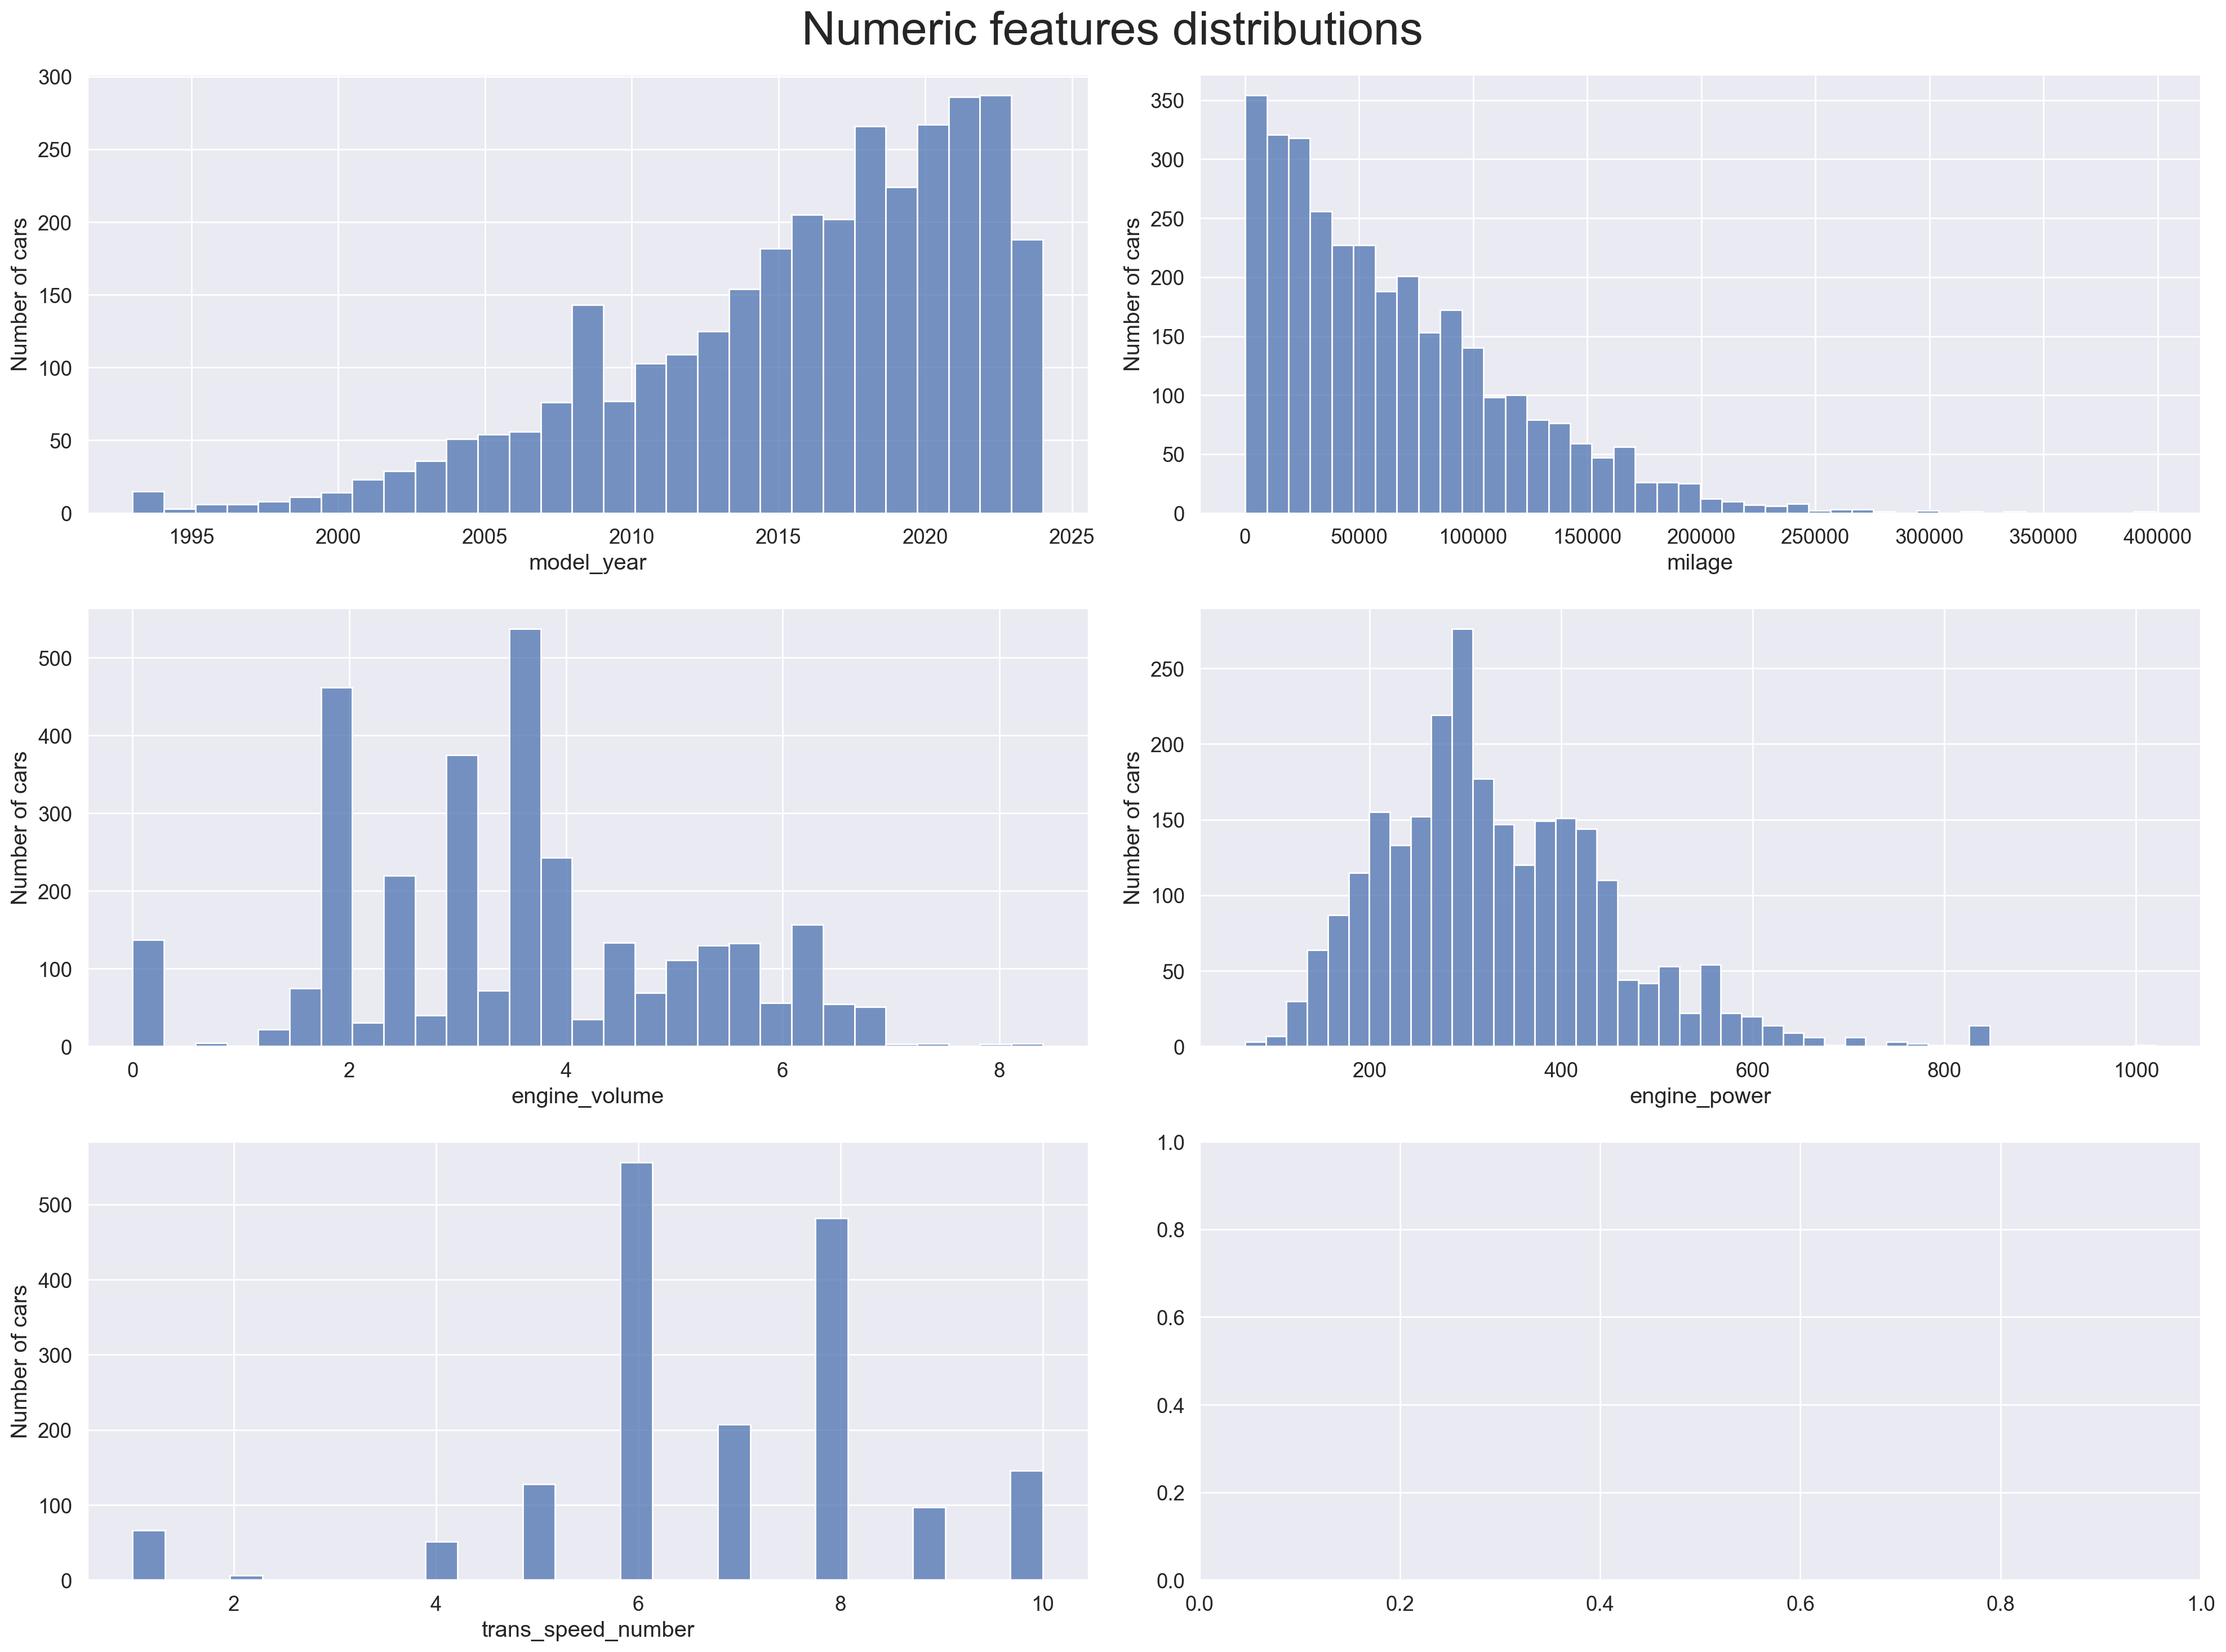

In [637]:
fig, axs = plt.subplots(3, 2, figsize=(20, 15))
axs = axs.reshape(-1)

fig.suptitle("Numeric features distributions", fontsize=30)
for i, feature in enumerate(numeric_cols):
    sns.histplot(data_train[feature], ax=axs[i]).set(ylabel=None)
    axs[i].set_ylabel("Number of cars")
plt.tight_layout()
plt.show()

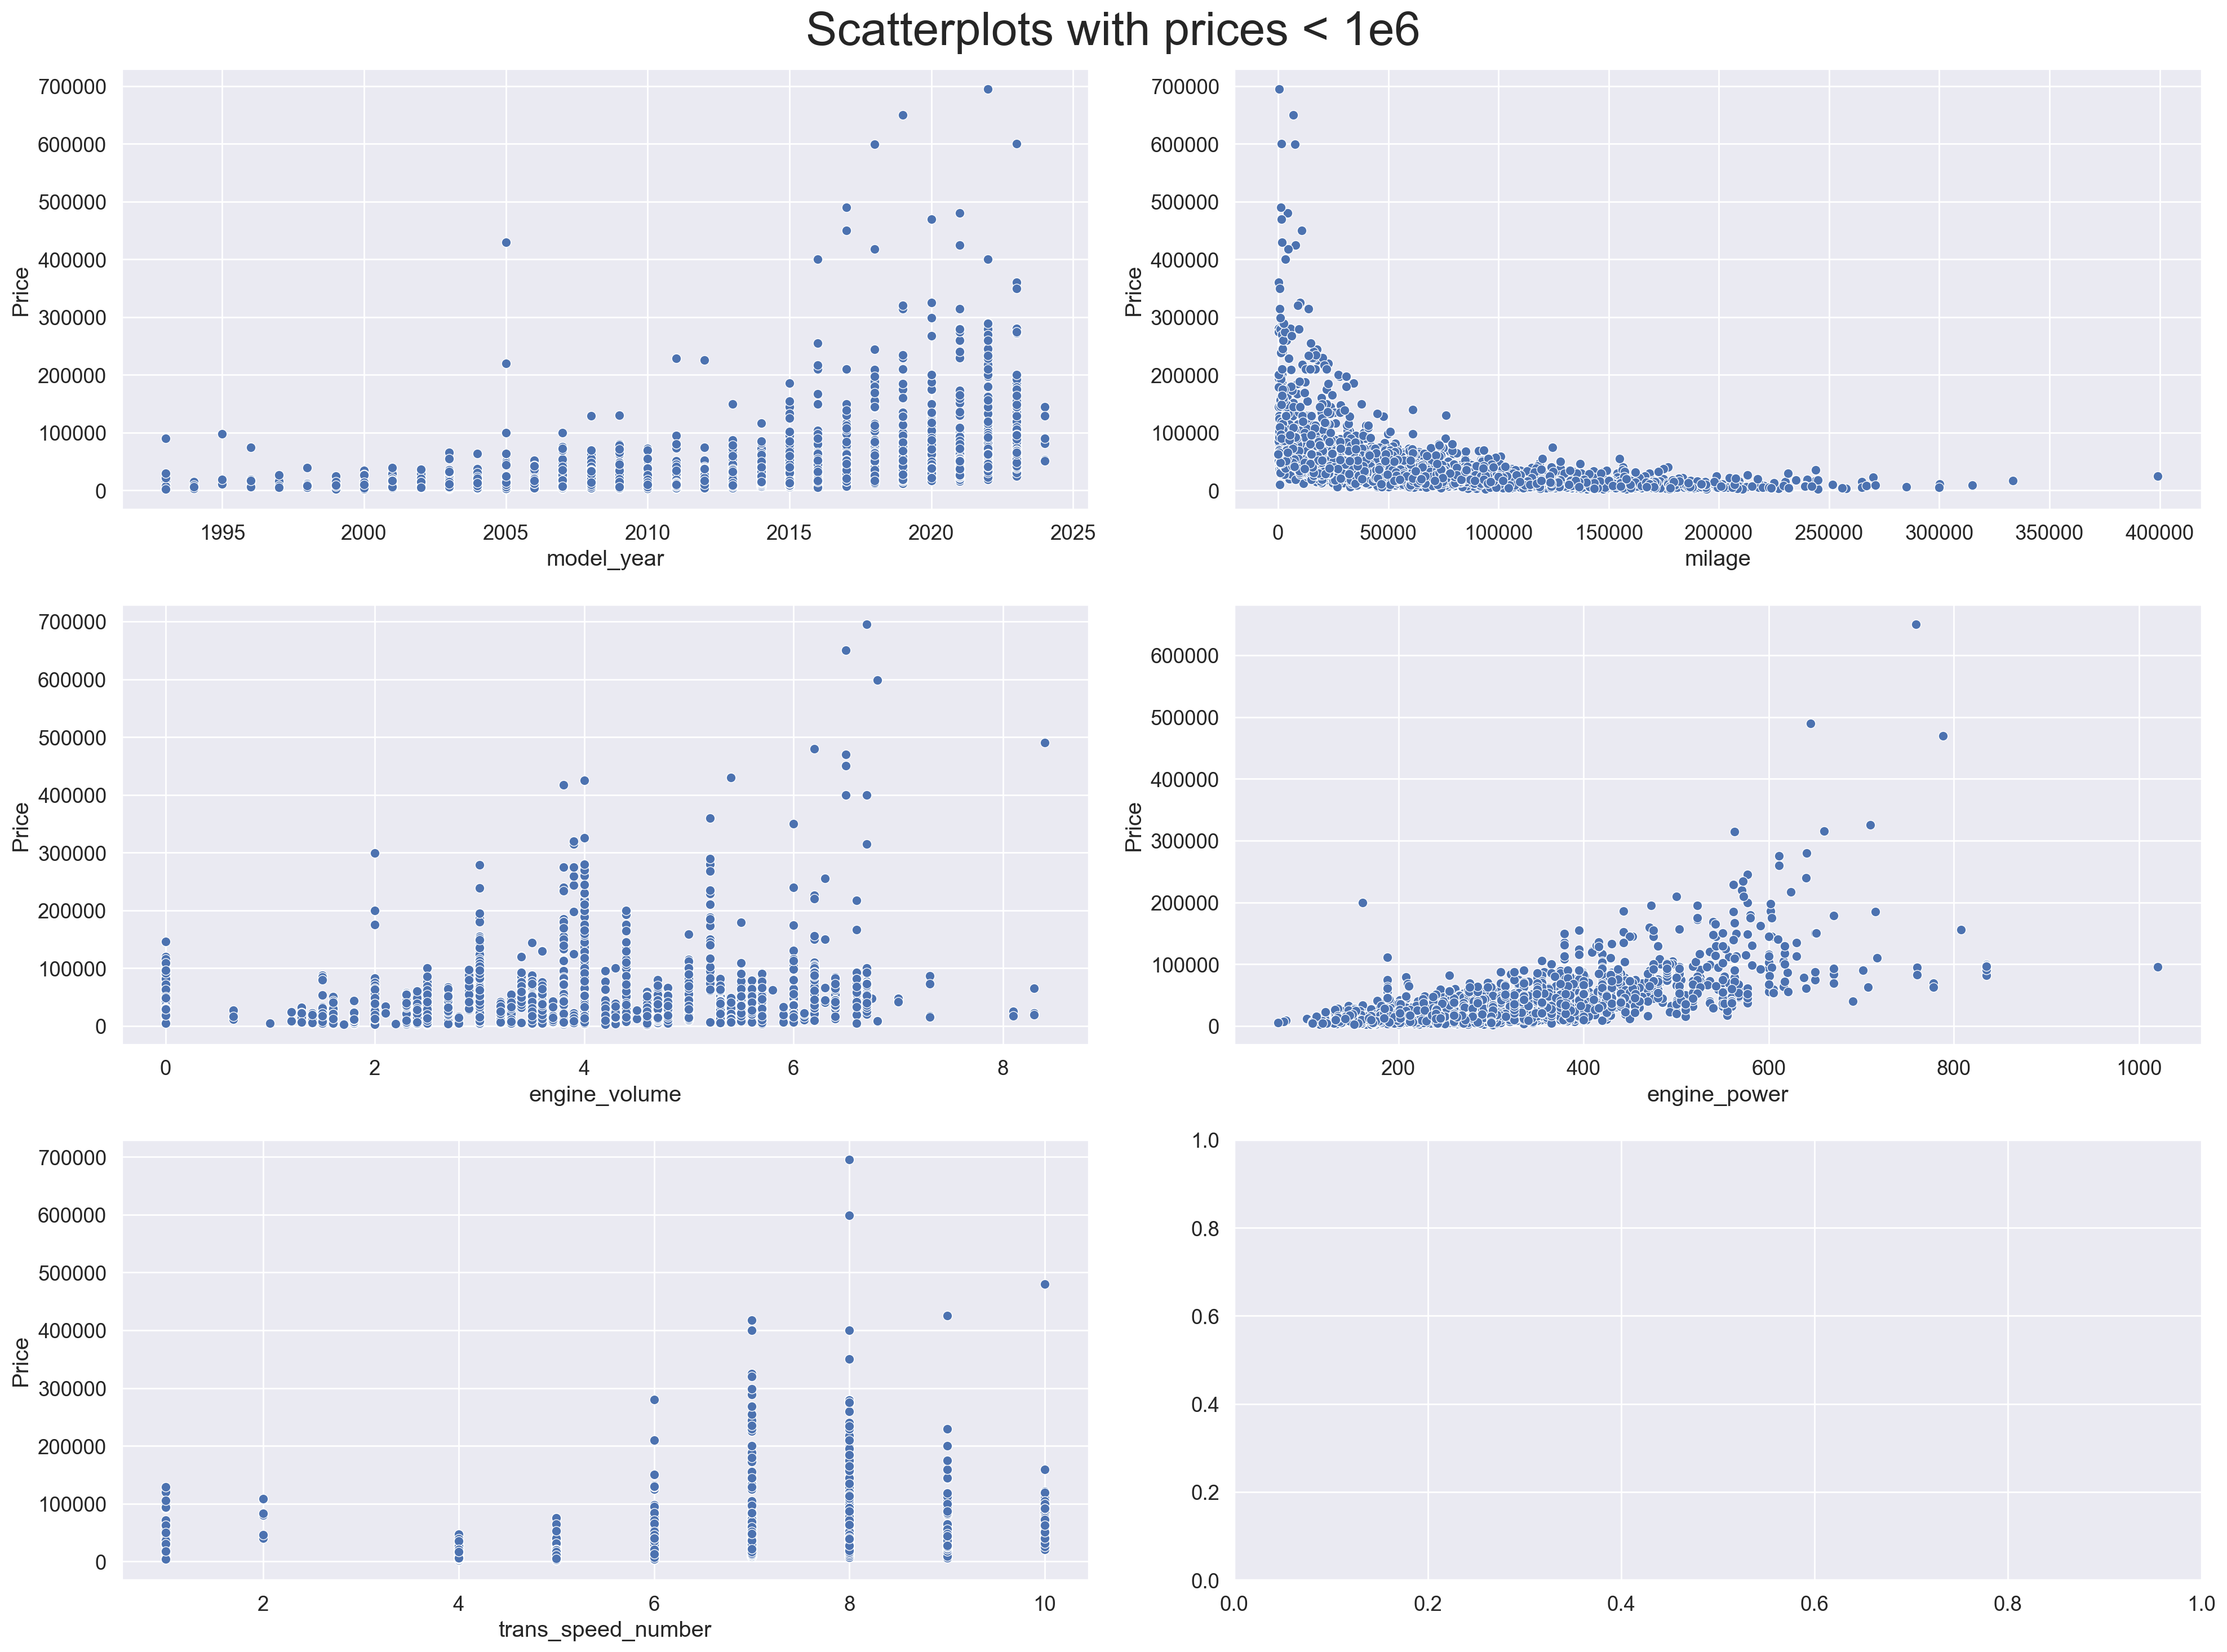

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(20, 15))
axs = axs.reshape(-1)

fig.suptitle("Scatterplots with prices < 1e6", fontsize=30)
for i, feature in enumerate(numeric_cols):
    sns.scatterplot(data = data_train[data_train["price"] < 1e6], x = feature, y="price", ax=axs[i]).set(ylabel=None)
    axs[i].set_ylabel("Price")
plt.tight_layout()

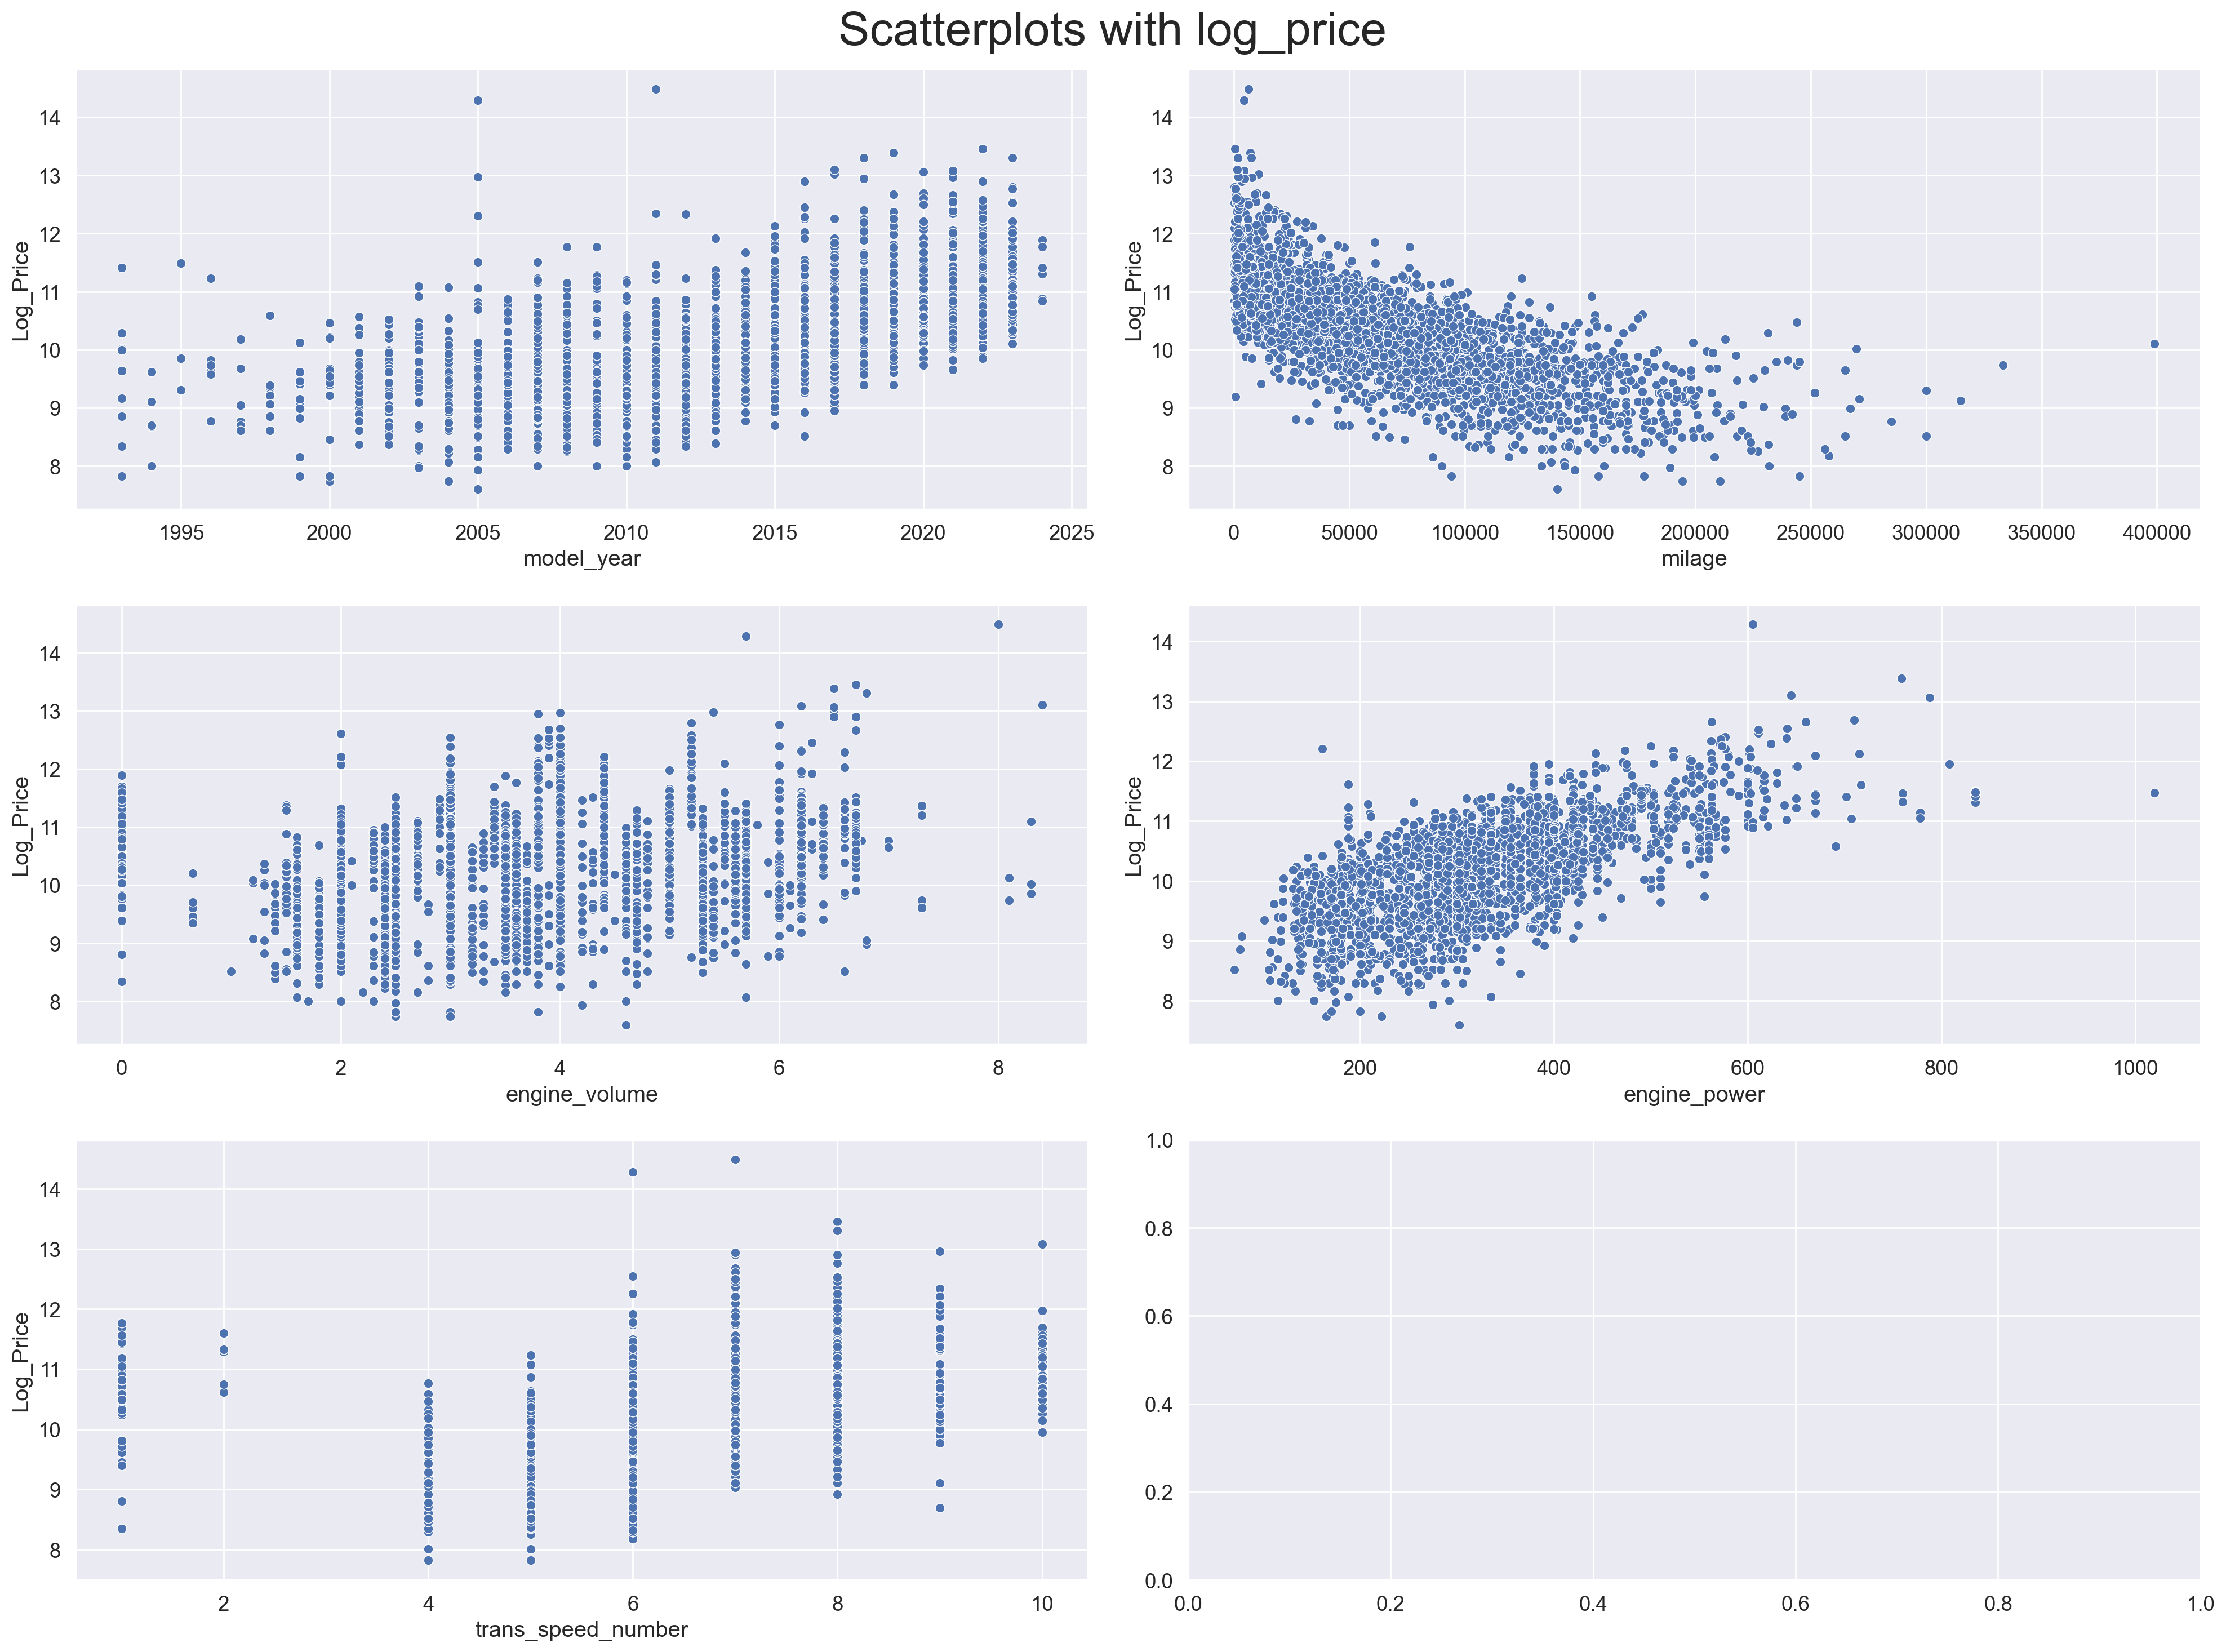

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(20, 15))
axs = axs.reshape(-1)


fig.suptitle("Scatterplots with log_price", fontsize=30)
for i, feature in enumerate(numeric_cols):
    sns.scatterplot(data = data_train, x = feature, y="log_price", ax=axs[i]).set(ylabel=None)
    axs[i].set_ylabel("Log_Price")
plt.tight_layout()

In [650]:
data_train[numeric_cols.tolist() + ["price", "log_price"]].corr().abs()[["price", "log_price"]]

,price,log_price
model_year,0.258660,0.637332
milage,0.361214,0.711242
engine_volume,0.168719,0.171449
engine_power,0.508332,0.673157
trans_speed_number,0.126643,0.327686
price,1.000000,0.660226
log_price,0.660226,1.000000


**Вывод:**
Логарифмирование таргета позволяет не только нормализовать его распределение, но и линеаризовать его зависимости от всех признаков. Корреляция признака и целевой переменной растет для всех численных признаков, для `model_year`, `milage` более/почти в 2 раза

**Гипотеза 5:** Линейная регрессия с логарифмированием таргета будет давать существенно более высокие результаты

**Замечание:** На данном этапе не добавляю преобразования признаков, однако по scatter графикам видим, что степенные преобразования могут также дополнительно увеличить корреляцию и линеаризовать зависимость логарифма цены от признака, например взятие квадратного корня из `milage`:

In [665]:
data_train[["milage", "price", "log_price"]].assign(milage_log = np.sqrt(data_train["milage"])).corr().abs()[["price", "log_price"]]

,price,log_price
milage,0.361214,0.711242
price,1.000000,0.660226
log_price,0.660226,1.000000
milage_log,0.422344,0.741308


**Замечание:** Для подбора степеней и создания полиномиальных фичей в будущем можно воспользоваться *regplot* с *lowess* аппроксимацией:

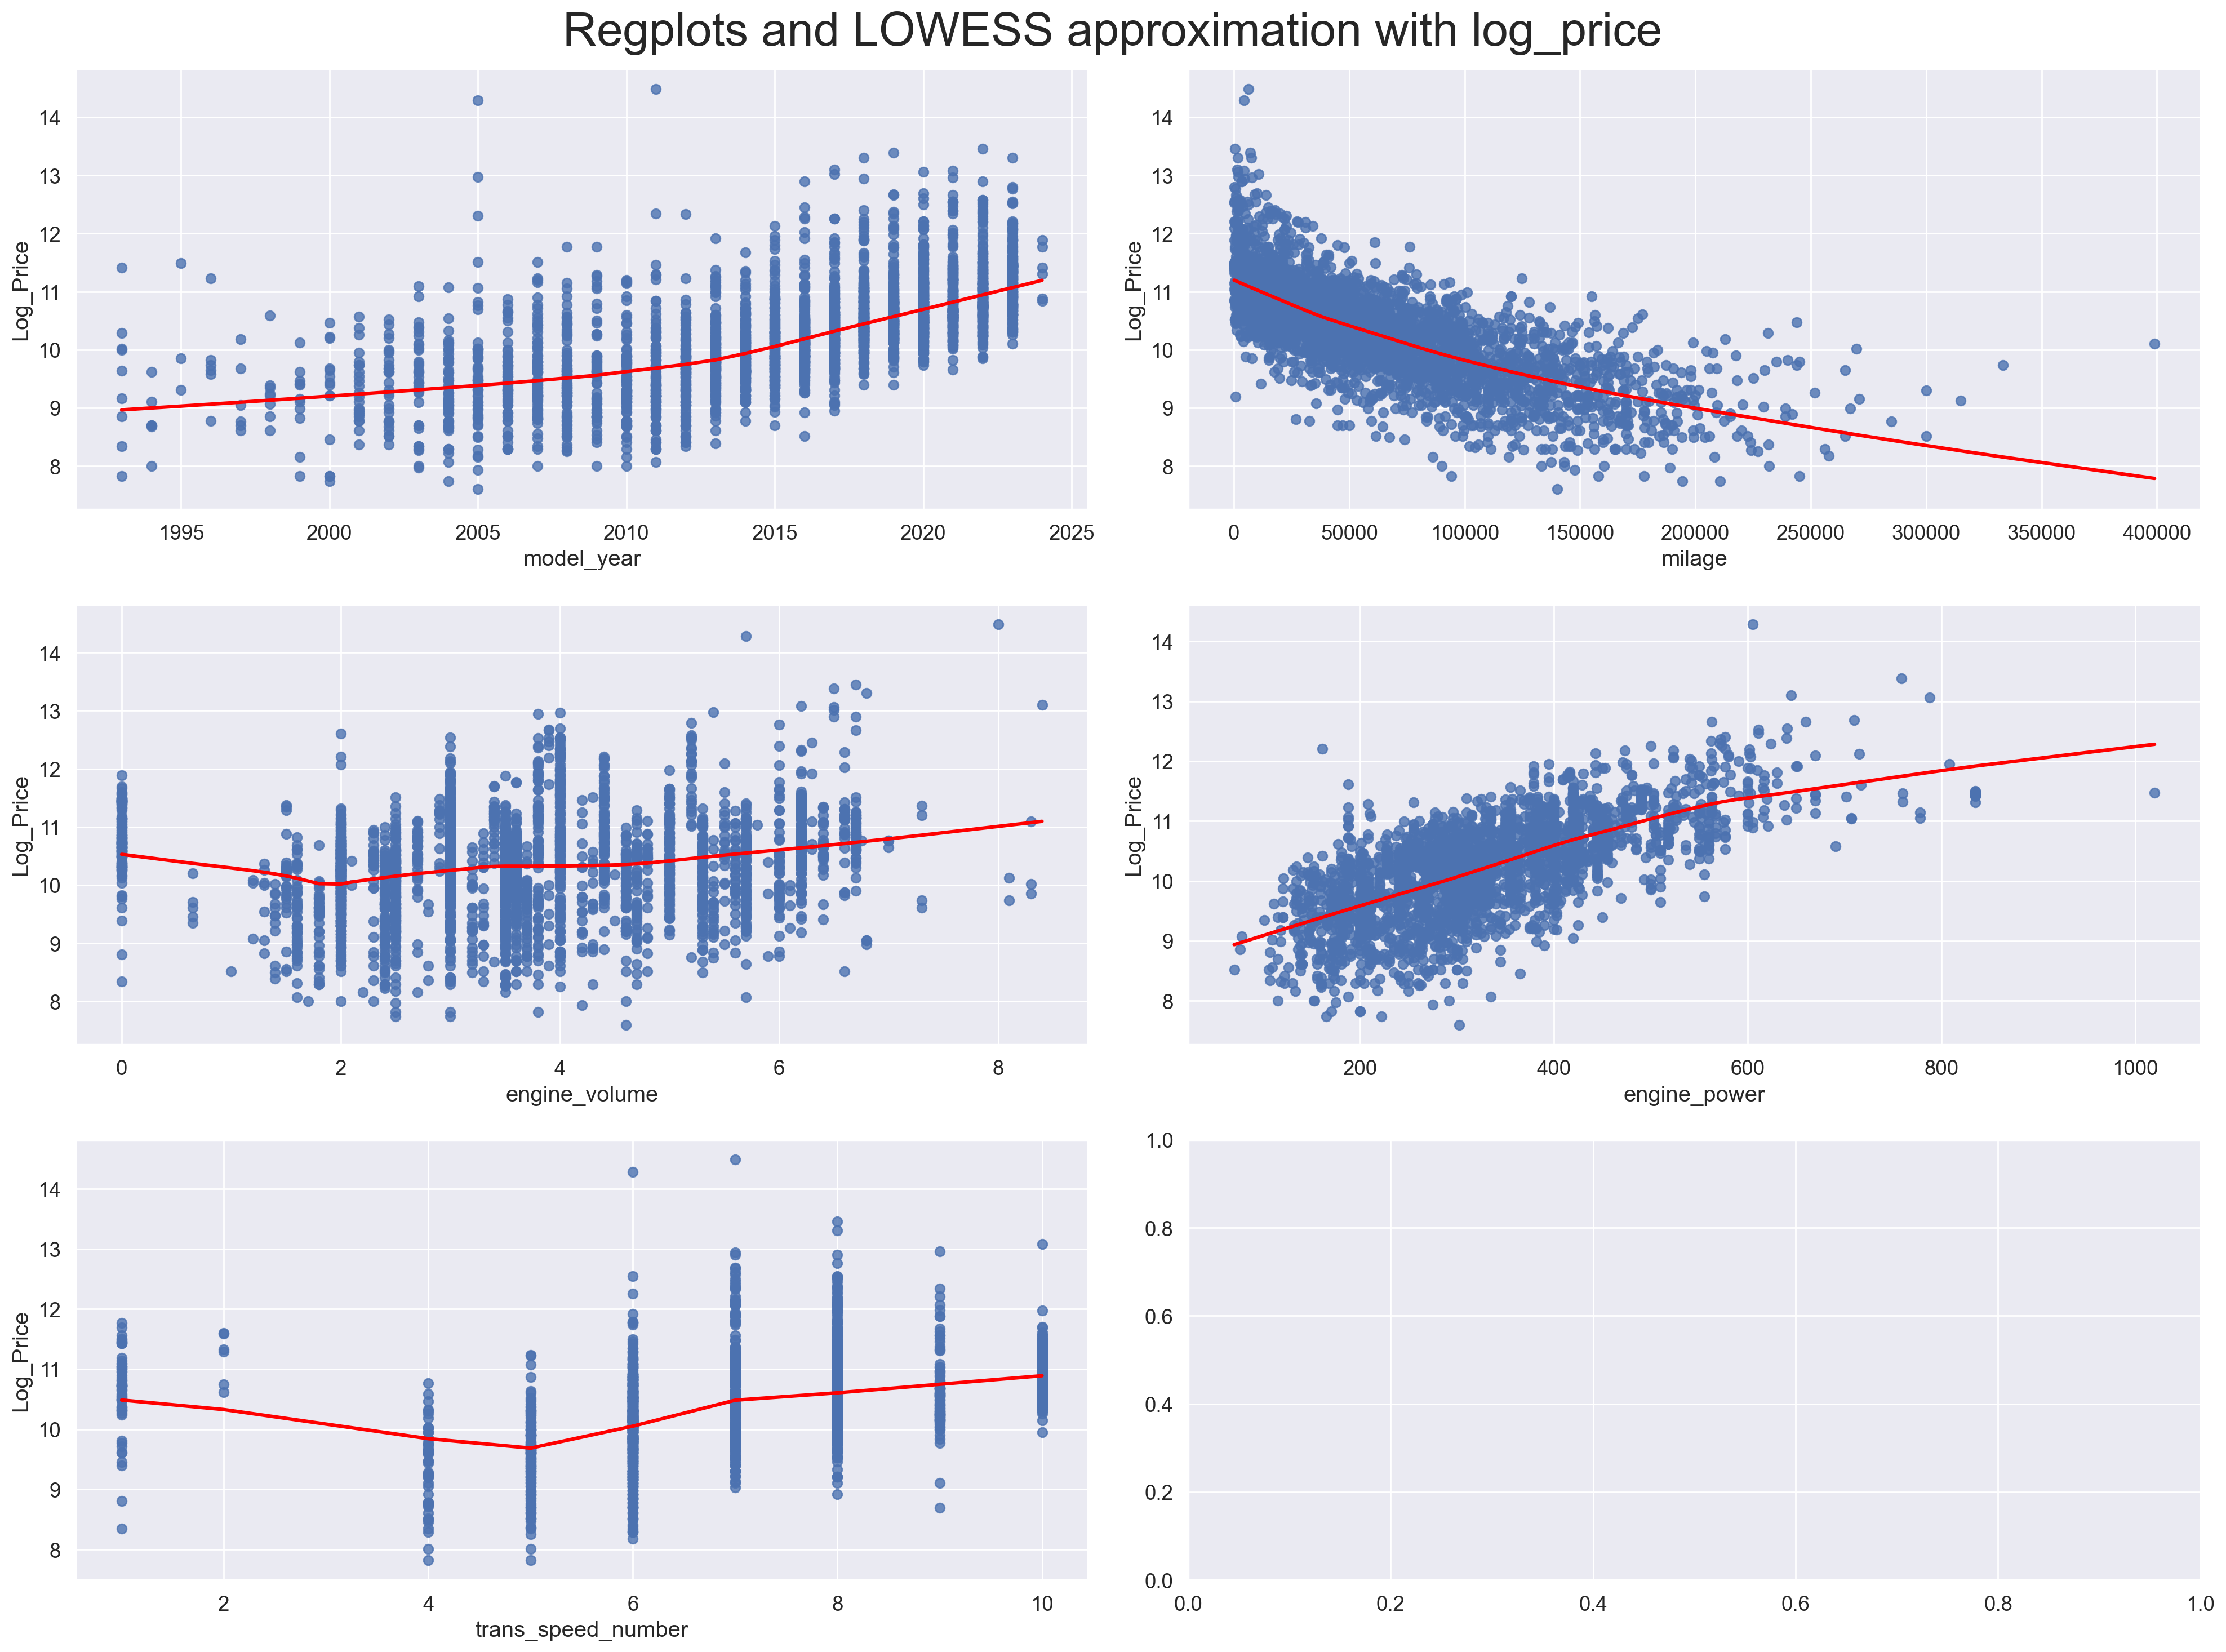

In [671]:
fig, axs = plt.subplots(3, 2, figsize=(20, 15))
axs = axs.reshape(-1)


fig.suptitle("Regplots and LOWESS approximation with log_price", fontsize=30)
for i, feature in enumerate(numeric_cols):
    sns.regplot(data=data_train, x=feature, y='log_price', ax=axs[i], lowess=True, line_kws={'color':'red'})
    axs[i].set_ylabel("Log_Price")
plt.tight_layout()
plt.show()

**Мини-вывод:** Зависимости не идеально линейные, но близки к ним. У признаков `engine_volume` и `trans_speed_number` линейную зависиомсть "портят" маленькие значения. В случае `engine_volume` это 0-ые значения, они будут учитываться с помощью бинарного `is_electric`, в случае `trans_speed_number` можно попробовать разделить признак по порогу 3.

In [672]:
arr = np.arange(16).reshape(4, 4)

In [674]:
arr[[0, 2], [1, 3]]

array([ 1, 11])

In [676]:
np.linspace(0, 10, 21)

array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
        5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. ])